## Merges all the availble information into a **Final Dataset** to be used for modeling ##

In [1]:
import pandas as pd
import datetime
import missingno
import re

from sklearn.impute import KNNImputer
import sys
import rpy2.robjects as robjects
import rpy2.ipython.html
from rpy2.robjects.packages import importr
import pickle
import gc

rpy2.ipython.html.init_printing()

sys.path.insert(0, "../../../Modules")
sys.path.insert(0, "../../../Mamoth")

from utils import *
from Neural_Network_Module import give_predictions, Dataset


enc = 'utf-8'
dec = 'greek8'

pd.options.display.max_columns = None
pd.options.display.max_rows = 100
pd.options.display.float_format = lambda x: '%.6f' % x

c:\Users\dimit\Python Virtual Environments\noa_eywa\Lib\site-packages\rpy2\robjects\packages.py:367: UserWarning: The symbol 'quartz' is not in this R namespace/package.
  warnings.warn(


In [2]:
utils = importr('utils')
base = importr('base')
dismo = importr('dismo')
utils.chooseCRANmirror(ind=41)

<rpy2.rinterface_lib.sexp.NULLType object at 0x000002D064272E10> [0]

In [3]:
NUTS0 = 'GR'
NUTS2 = 'CMacedonia'

In [4]:
years = range(2024, 2025)

In [5]:
timelines = []

for year in years:
    df = pd.read_csv(f'../../data/{NUTS2}/{NUTS0}_{NUTS2}_Timeline_GRID_{year}_filled_mean_rain_shp.csv', encoding=enc)
    print(f'Year: {year} | {df.shape}')
    timelines.append(df)

Year: 2024 | (808128, 44)


In [6]:
# timeline_file = pd.read_csv(f'../../data/{NUTS2}/{NUTS0}_{NUTS2}_Timeline_GRID_2016-2018_filled.csv', encoding=enc)
# wnv_file = pd.read_csv(f'../../data/{NUTS0}_WNV_cases_GRID_2010-2021.csv', encoding=enc)

timeline_file = pd.concat(timelines, ignore_index=True, axis = 0)

In [7]:
del df
del timelines

gc.collect()

270

In [8]:
timeline_file.head()

,x,y,cell_number,dt_placement,NUTS1_ID,NUTS1_NAME,NUTS2_ID,NUTS2_NAME,NUTS3_ID,NUTS3_NAME,LAU1_NAME,year,month,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst_day,lst_night,rainfall,day,lst_day_jan_mean,lst_night_jan_mean,lst_day_feb_mean,lst_night_feb_mean,lst_day_mar_mean,lst_night_mar_mean,lst_day_apr_mean,lst_night_apr_mean,acc_rainfall_1week,acc_rainfall_2week,acc_rainfall_month,acc_rainfall_jan,MOUNT_TYPE,URBN_TYPE,COAST_TYPE
0,21.763340,40.798060,0,2024-01-01,EL5,βορεια ελλαδα,EL52,κεντρικη μακεδονια,EL524,πελλα,εδεσσας,2024,1,0.329513,-0.087897,-0.308622,0.087897,0.321240,-0.084725,-0.298909,0.084725,0.024682,0.037362,0.017980,0.037362,13797.000000,13711.000000,0.004594,1,13979.161290,13704.419355,14168.620690,13794.379310,14355.870968,13787.225806,14829.360000,14100.120000,0.004594,0.004594,0.004594,0.004594,2.000000,3,2
1,21.763340,40.798060,0,2024-01-02,EL5,βορεια ελλαδα,EL52,κεντρικη μακεδονια,EL524,πελλα,εδεσσας,2024,1,0.329513,-0.087897,-0.308622,0.087897,0.321240,-0.084725,-0.298909,0.084725,0.024682,0.037362,0.017980,0.037362,14001.000000,13890.000000,3.881401,2,13979.161290,13704.419355,14168.620690,13794.379310,14355.870968,13787.225806,14829.360000,14100.120000,3.885995,3.885995,3.885995,3.885995,2.000000,3,2
2,21.763340,40.798060,0,2024-01-03,EL5,βορεια ελλαδα,EL52,κεντρικη μακεδονια,EL524,πελλα,εδεσσας,2024,1,0.329513,-0.087897,-0.308622,0.087897,0.321240,-0.084725,-0.298909,0.084725,0.024682,0.037362,0.017980,0.037362,14001.000000,13905.000000,5.104080,3,13979.161290,13704.419355,14168.620690,13794.379310,14355.870968,13787.225806,14829.360000,14100.120000,8.990075,8.990075,8.990075,8.990075,2.000000,3,2
3,21.763340,40.798060,0,2024-01-04,EL5,βορεια ελλαδα,EL52,κεντρικη μακεδονια,EL524,πελλα,εδεσσας,2024,1,0.329513,-0.087897,-0.308622,0.087897,0.321240,-0.084725,-0.298909,0.084725,0.024682,0.037362,0.017980,0.037362,14132.000000,14057.000000,0.035872,4,13979.161290,13704.419355,14168.620690,13794.379310,14355.870968,13787.225806,14829.360000,14100.120000,9.025947,9.025947,9.025947,9.025947,2.000000,3,2
4,21.763340,40.798060,0,2024-01-05,EL5,βορεια ελλαδα,EL52,κεντρικη μακεδονια,EL524,πελλα,εδεσσας,2024,1,0.329513,-0.087897,-0.308622,0.087897,0.321240,-0.084725,-0.298909,0.084725,0.024682,0.037362,0.017980,0.037362,14132.000000,14057.000000,0.000000,5,13979.161290,13704.419355,14168.620690,13794.379310,14355.870968,13787.225806,14829.360000,14100.120000,9.025947,9.025947,9.025947,9.025947,2.000000,3,2


In [9]:
timeline_file.shape

(808128, 44)

In [10]:
# wnv_file.head()

In [11]:
# wnv_file.shape

In [12]:
try:
    timeline_file.drop(columns=['Unnamed: 0'], inplace=True)
except KeyError:
    print ("column not found")

column not found


In [13]:
temprature_cols = timeline_file.filter(regex='^lst_*').columns.tolist()

timeline_file[temprature_cols] = timeline_file[temprature_cols].apply(lambda x : x * 0.02 - 273.15)

In [14]:
timeline_file.head()

,x,y,cell_number,dt_placement,NUTS1_ID,NUTS1_NAME,NUTS2_ID,NUTS2_NAME,NUTS3_ID,NUTS3_NAME,LAU1_NAME,year,month,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst_day,lst_night,rainfall,day,lst_day_jan_mean,lst_night_jan_mean,lst_day_feb_mean,lst_night_feb_mean,lst_day_mar_mean,lst_night_mar_mean,lst_day_apr_mean,lst_night_apr_mean,acc_rainfall_1week,acc_rainfall_2week,acc_rainfall_month,acc_rainfall_jan,MOUNT_TYPE,URBN_TYPE,COAST_TYPE
0,21.763340,40.798060,0,2024-01-01,EL5,βορεια ελλαδα,EL52,κεντρικη μακεδονια,EL524,πελλα,εδεσσας,2024,1,0.329513,-0.087897,-0.308622,0.087897,0.321240,-0.084725,-0.298909,0.084725,0.024682,0.037362,0.017980,0.037362,2.790000,1.070000,0.004594,1,6.433226,0.938387,10.222414,2.737586,13.967419,2.594516,23.437200,8.852400,0.004594,0.004594,0.004594,0.004594,2.000000,3,2
1,21.763340,40.798060,0,2024-01-02,EL5,βορεια ελλαδα,EL52,κεντρικη μακεδονια,EL524,πελλα,εδεσσας,2024,1,0.329513,-0.087897,-0.308622,0.087897,0.321240,-0.084725,-0.298909,0.084725,0.024682,0.037362,0.017980,0.037362,6.870000,4.650000,3.881401,2,6.433226,0.938387,10.222414,2.737586,13.967419,2.594516,23.437200,8.852400,3.885995,3.885995,3.885995,3.885995,2.000000,3,2
2,21.763340,40.798060,0,2024-01-03,EL5,βορεια ελλαδα,EL52,κεντρικη μακεδονια,EL524,πελλα,εδεσσας,2024,1,0.329513,-0.087897,-0.308622,0.087897,0.321240,-0.084725,-0.298909,0.084725,0.024682,0.037362,0.017980,0.037362,6.870000,4.950000,5.104080,3,6.433226,0.938387,10.222414,2.737586,13.967419,2.594516,23.437200,8.852400,8.990075,8.990075,8.990075,8.990075,2.000000,3,2
3,21.763340,40.798060,0,2024-01-04,EL5,βορεια ελλαδα,EL52,κεντρικη μακεδονια,EL524,πελλα,εδεσσας,2024,1,0.329513,-0.087897,-0.308622,0.087897,0.321240,-0.084725,-0.298909,0.084725,0.024682,0.037362,0.017980,0.037362,9.490000,7.990000,0.035872,4,6.433226,0.938387,10.222414,2.737586,13.967419,2.594516,23.437200,8.852400,9.025947,9.025947,9.025947,9.025947,2.000000,3,2
4,21.763340,40.798060,0,2024-01-05,EL5,βορεια ελλαδα,EL52,κεντρικη μακεδονια,EL524,πελλα,εδεσσας,2024,1,0.329513,-0.087897,-0.308622,0.087897,0.321240,-0.084725,-0.298909,0.084725,0.024682,0.037362,0.017980,0.037362,9.490000,7.990000,0.000000,5,6.433226,0.938387,10.222414,2.737586,13.967419,2.594516,23.437200,8.852400,9.025947,9.025947,9.025947,9.025947,2.000000,3,2


In [15]:
timeline_file['lst'] = (timeline_file['lst_day'] + timeline_file['lst_night']) / 2
timeline_file['lst_jan_mean'] = (timeline_file['lst_day_jan_mean'] + timeline_file['lst_night_jan_mean'])/2
timeline_file['lst_feb_mean'] = (timeline_file['lst_day_feb_mean'] + timeline_file['lst_night_feb_mean'])/2
timeline_file['lst_mar_mean'] = (timeline_file['lst_day_mar_mean'] + timeline_file['lst_night_mar_mean'])/2
timeline_file['lst_apr_mean'] = (timeline_file['lst_day_apr_mean'] + timeline_file['lst_night_apr_mean'])/2

In [16]:
timeline_file['dt_placement'] = pd.to_datetime(timeline_file['dt_placement'])
timeline_file['day'] = timeline_file['dt_placement'].apply(lambda x : x.day)
timeline_file['month'] = timeline_file['dt_placement'].apply(lambda x : x.month)
timeline_file['year'] = timeline_file['dt_placement'].apply(lambda x : x.year)

timeline_file = encode_cyclical(timeline_file, 'month', 12)

In [17]:
timeline_file.rename(columns={"lst_day_jan_mean": "lst_jan_day_mean",
                        "lst_day_feb_mean": "lst_feb_day_mean",
                        "lst_day_mar_mean": "lst_mar_day_mean",
                        "lst_day_apr_mean": "lst_apr_day_mean",
                        "lst_night_jan_mean": "lst_jan_night_mean",
                        "lst_night_feb_mean": "lst_feb_night_mean",
                        "lst_night_mar_mean": "lst_mar_night_mean",
                        "lst_night_apr_mean": "lst_apr_night_mean"}, inplace=True)

In [18]:
timeline_file

,x,y,cell_number,dt_placement,NUTS1_ID,NUTS1_NAME,NUTS2_ID,NUTS2_NAME,NUTS3_ID,NUTS3_NAME,LAU1_NAME,year,month,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst_day,lst_night,rainfall,day,lst_jan_day_mean,lst_jan_night_mean,lst_feb_day_mean,lst_feb_night_mean,lst_mar_day_mean,lst_mar_night_mean,lst_apr_day_mean,lst_apr_night_mean,acc_rainfall_1week,acc_rainfall_2week,acc_rainfall_month,acc_rainfall_jan,MOUNT_TYPE,URBN_TYPE,COAST_TYPE,lst,lst_jan_mean,lst_feb_mean,lst_mar_mean,lst_apr_mean,month_sin,month_cos
0,21.763340,40.798060,0,2024-01-01,EL5,βορεια ελλαδα,EL52,κεντρικη μακεδονια,EL524,πελλα,εδεσσας,2024,1,0.329513,-0.087897,-0.308622,0.087897,0.321240,-0.084725,-0.298909,0.084725,0.024682,0.037362,0.017980,0.037362,2.790000,1.070000,0.004594,1,6.433226,0.938387,10.222414,2.737586,13.967419,2.594516,23.437200,8.852400,0.004594,0.004594,0.004594,0.004594,2.000000,3,2,1.930000,3.685806,6.480000,8.280968,16.144800,0.500000,0.866025
1,21.763340,40.798060,0,2024-01-02,EL5,βορεια ελλαδα,EL52,κεντρικη μακεδονια,EL524,πελλα,εδεσσας,2024,1,0.329513,-0.087897,-0.308622,0.087897,0.321240,-0.084725,-0.298909,0.084725,0.024682,0.037362,0.017980,0.037362,6.870000,4.650000,3.881401,2,6.433226,0.938387,10.222414,2.737586,13.967419,2.594516,23.437200,8.852400,3.885995,3.885995,3.885995,3.885995,2.000000,3,2,5.760000,3.685806,6.480000,8.280968,16.144800,0.500000,0.866025
2,21.763340,40.798060,0,2024-01-03,EL5,βορεια ελλαδα,EL52,κεντρικη μακεδονια,EL524,πελλα,εδεσσας,2024,1,0.329513,-0.087897,-0.308622,0.087897,0.321240,-0.084725,-0.298909,0.084725,0.024682,0.037362,0.017980,0.037362,6.870000,4.950000,5.104080,3,6.433226,0.938387,10.222414,2.737586,13.967419,2.594516,23.437200,8.852400,8.990075,8.990075,8.990075,8.990075,2.000000,3,2,5.910000,3.685806,6.480000,8.280968,16.144800,0.500000,0.866025
3,21.763340,40.798060,0,2024-01-04,EL5,βορεια ελλαδα,EL52,κεντρικη μακεδονια,EL524,πελλα,εδεσσας,2024,1,0.329513,-0.087897,-0.308622,0.087897,0.321240,-0.084725,-0.298909,0.084725,0.024682,0.037362,0.017980,0.037362,9.490000,7.990000,0.035872,4,6.433226,0.938387,10.222414,2.737586,13.967419,2.594516,23.437200,8.852400,9.025947,9.025947,9.025947,9.025947,2.000000,3,2,8.740000,3.685806,6.480000,8.280968,16.144800,0.500000,0.866025
4,21.763340,40.798060,0,2024-01-05,EL5,βορεια ελλαδα,EL52,κεντρικη μακεδονια,EL524,πελλα,εδεσσας,2024,1,0.329513,-0.087897,-0.308622,0.087897,0.321240,-0.084725,-0.298909,0.084725,0.024682,0.037362,0.017980,0.037362,9.490000,7.990000,0.000000,5,6.433226,0.938387,10.222414,2.737586,13.967419,2.594516,23.437200,8.852400,9.025947,9.025947,9.025947,9.025947,2.000000,3,2,8.740000,3.685806,6.480000,8.280968,16.144800,0.500000,0.866025
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
808123,24.082170,40.995700,4415,2024-06-27,EL5,βορεια ελλαδα,EL52,κεντρικη μακεδονια,EL526,σερρες,αμφιπολης,2024,6,0.249392,-0.054278,-0.324742,0.054278,0.252126,-0.043821,-0.330262,0.043821,0.076297,0.073261,0.035246,0.073261,36.370000,22.030000,NaN,27,7.102258,1.270000,13.327241,3.378276,15.694516,6.602903,25.850000,10.997200,0.000000,0.000000,0.000000,273.645107,2.000000,3,1,29.200000,4.186129,8.352759,11.148710,18.423600,0.000000,-1.000000
808124,24.082170,40.995700,4415,2024-06-28,EL5,βορεια ελλαδα,EL52,κεντρικη μακεδονια,EL526,σερρες,αμφιπολης,2024,6,0.249392,-0.054278,-0.324742,0.054278,0.252126,-0.043821,-0.330262,0.043821,0.076297,0.073261,0.035246,0.073261,36.370000,20.970000,NaN,28,7.102258,1.270000,13.327241,3.378276,15.694516,6.602903,25.850000,10.997200,0.000000,0.000000,0.000000,273.645107,2.000000,3,1,28.670000,4.186129,8.352759,11.148710,18.423600,0.000000,-1.000000
808125,24.082170,40.995700,4415,2024-06-29,EL5,βορεια ελλαδα,EL52,κεντρικη μακεδονια,EL526,σερρες,αμφιπολης,2024,6,0.249392,-0.054278,-0.324742,0.054278,0.252126,-0.04

In [19]:
timeline_file.rename(columns={"dt_placement": "dt_placement_daily"}, inplace=True)
timeline_file['date_string'] = timeline_file['month'].astype(str) + '-' + timeline_file['year'].astype(str)
timeline_file['dt_placement'] = pd.to_datetime(timeline_file['date_string'], format='%m-%Y').dt.to_period('M')
timeline_file.drop(columns=['date_string'], inplace = True)

In [20]:
gc.collect()

0

In [21]:
grouped_by_month = timeline_file.drop(columns=['dt_placement_daily']).groupby(['cell_number','dt_placement','NUTS1_ID','NUTS1_NAME','NUTS2_ID','NUTS2_NAME','NUTS3_ID', 'NUTS3_NAME', 'LAU1_NAME'], as_index = False)

grouped_by_month_mean = grouped_by_month.mean()
grouped_by_month_min = grouped_by_month.min()
grouped_by_month_max = grouped_by_month.max()
grouped_by_month_sum = grouped_by_month.sum()
grouped_by_month_last = grouped_by_month.last()

In [22]:
del timeline_file
gc.collect()

0

In [23]:
grouped_by_month_dataset = pd.concat([grouped_by_month_mean[['cell_number','dt_placement','NUTS1_ID','NUTS1_NAME','NUTS2_ID','NUTS2_NAME','NUTS3_ID','NUTS3_NAME','LAU1_NAME','x','y','MOUNT_TYPE','URBN_TYPE','COAST_TYPE','year','month']], 
                                     grouped_by_month_mean[['ndvi','ndmi','ndwi','ndbi','ndvi_mean','ndmi_mean','ndwi_mean','ndbi_mean','ndvi_std','ndmi_std','ndwi_std','ndbi_std']],
                                     grouped_by_month_mean[['lst_day','lst_night','lst']].rename(columns={'lst_day': 'lst_day_mean', 'lst_night': 'lst_night_mean', 'lst': 'lst_mean'}),
                                     grouped_by_month_last[['lst_jan_day_mean','lst_feb_day_mean','lst_mar_day_mean','lst_apr_day_mean', 'lst_jan_night_mean','lst_feb_night_mean','lst_mar_night_mean','lst_apr_night_mean','lst_jan_mean','lst_feb_mean','lst_mar_mean','lst_apr_mean']],
                                     grouped_by_month_mean[['rainfall']].rename(columns={'rainfall':'rainfall_mean'}),
                                     grouped_by_month_last[['acc_rainfall_1week','acc_rainfall_2week','acc_rainfall_month','acc_rainfall_jan']],
                                     grouped_by_month_min[['lst_day','lst_night']].rename(columns={'lst_day':'lst_day_min', 'lst_night': 'lst_night_min'}),
                                     grouped_by_month_max[['lst_day','lst_night']].rename(columns={'lst_day':'lst_day_max', 'lst_night': 'lst_night_max'}),
                                     grouped_by_month_sum[['rainfall']].rename(columns={'rainfall':'rainfall_acc'})], axis=1)

In [24]:
del grouped_by_month
del grouped_by_month_mean
del grouped_by_month_min
del grouped_by_month_max
del grouped_by_month_sum
del grouped_by_month_last

gc.collect()

0

In [25]:
grouped_by_month_dataset.head()

,cell_number,dt_placement,NUTS1_ID,NUTS1_NAME,NUTS2_ID,NUTS2_NAME,NUTS3_ID,NUTS3_NAME,LAU1_NAME,x,y,MOUNT_TYPE,URBN_TYPE,COAST_TYPE,year,month,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst_day_mean,lst_night_mean,lst_mean,lst_jan_day_mean,lst_feb_day_mean,lst_mar_day_mean,lst_apr_day_mean,lst_jan_night_mean,lst_feb_night_mean,lst_mar_night_mean,lst_apr_night_mean,lst_jan_mean,lst_feb_mean,lst_mar_mean,lst_apr_mean,rainfall_mean,acc_rainfall_1week,acc_rainfall_2week,acc_rainfall_month,acc_rainfall_jan,lst_day_min,lst_night_min,lst_day_max,lst_night_max,rainfall_acc
0,0,2024-01,EL5,βορεια ελλαδα,EL52,κεντρικη μακεδονια,EL524,πελλα,εδεσσας,21.763340,40.798060,2.000000,3.000000,2.000000,2024.000000,1.000000,0.267415,0.083574,-0.257810,-0.083574,0.241783,0.021266,-0.224117,-0.021266,0.021016,0.055956,0.024599,0.055956,6.433226,0.938387,3.685806,6.433226,10.222414,13.967419,23.437200,0.938387,2.737586,2.594516,8.852400,3.685806,6.480000,8.280968,16.144800,1.467828,7.611751,16.225668,45.498087,45.502681,-0.710000,-6.610000,12.870000,7.990000,45.502681
1,0,2024-02,EL5,βορεια ελλαδα,EL52,κεντρικη μακεδονια,EL524,πελλα,εδεσσας,21.763340,40.798060,2.000000,3.000000,2.000000,2024.000000,2.000000,0.244531,0.146571,-0.258886,-0.146571,0.290309,-0.085296,-0.307094,0.085296,0.023339,0.022974,0.011478,0.022974,10.222414,2.737586,6.480000,6.433226,10.222414,13.967419,23.437200,0.938387,2.737586,2.594516,8.852400,3.685806,6.480000,8.280968,16.144800,1.294299,18.881823,18.951474,37.534668,83.037349,4.630000,-5.290000,14.110000,7.350000,37.534668
2,0,2024-03,EL5,βορεια ελλαδα,EL52,κεντρικη μακεδονια,EL524,πελλα,εδεσσας,21.763340,40.798060,2.000000,3.000000,2.000000,2024.000000,3.000000,0.324030,-0.109920,-0.337069,0.109920,0.306936,-0.100461,-0.321696,0.100461,0.025461,0.024213,0.015288,0.024213,13.967419,2.594516,8.280968,6.433226,10.222414,13.967419,23.437200,0.938387,2.737586,2.594516,8.852400,3.685806,6.480000,8.280968,16.144800,1.551360,11.947780,14.171614,29.937022,129.578139,5.770000,-4.570000,24.350000,9.830000,46.540790
3,0,2024-04,EL5,βορεια ελλαδα,EL52,κεντρικη μακεδονια,EL524,πελλα,εδεσσας,21.763340,40.798060,2.000000,3.000000,2.000000,2024.000000,4.000000,0.498411,0.043862,-0.419718,-0.043862,0.471756,0.023727,-0.406067,-0.023727,0.044087,0.046540,0.023812,0.046540,23.437200,8.852400,16.144800,6.433226,10.222414,13.967419,23.437200,0.938387,2.737586,2.594516,8.852400,3.685806,6.480000,8.280968,16.144800,2.423561,0.703507,60.256993,70.283258,199.861397,16.490000,-1.550000,29.210000,15.190000,70.283258
4,0,2024-05,EL5,βορεια ελλαδα,EL52,κεντρικη μακεδονια,EL524,πελλα,εδεσσας,21.763340,40.798060,2.000000,3.000000,2.000000,2024.000000,5.000000,0.666505,0.221835,-0.546680,-0.221835,0.635158,0.202725,-0.527143,-0.202725,0.052198,0.064876,0.035096,0.064876,19.902143,11.425714,15.663929,6.433226,10.222414,13.967419,23.437200,0.938387,2.737586,2.594516,8.852400,3.685806,6.480000,8.280968,16.144800,2.358295,0.697901,22.902835,70.748837,270.610234,7.050000,3.590000,27.530000,15.570000,70.748837


In [26]:
grouped_by_month_dataset

,cell_number,dt_placement,NUTS1_ID,NUTS1_NAME,NUTS2_ID,NUTS2_NAME,NUTS3_ID,NUTS3_NAME,LAU1_NAME,x,y,MOUNT_TYPE,URBN_TYPE,COAST_TYPE,year,month,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst_day_mean,lst_night_mean,lst_mean,lst_jan_day_mean,lst_feb_day_mean,lst_mar_day_mean,lst_apr_day_mean,lst_jan_night_mean,lst_feb_night_mean,lst_mar_night_mean,lst_apr_night_mean,lst_jan_mean,lst_feb_mean,lst_mar_mean,lst_apr_mean,rainfall_mean,acc_rainfall_1week,acc_rainfall_2week,acc_rainfall_month,acc_rainfall_jan,lst_day_min,lst_night_min,lst_day_max,lst_night_max,rainfall_acc
0,0,2024-01,EL5,βορεια ελλαδα,EL52,κεντρικη μακεδονια,EL524,πελλα,εδεσσας,21.763340,40.798060,2.000000,3.000000,2.000000,2024.000000,1.000000,0.267415,0.083574,-0.257810,-0.083574,0.241783,0.021266,-0.224117,-0.021266,0.021016,0.055956,0.024599,0.055956,6.433226,0.938387,3.685806,6.433226,10.222414,13.967419,23.437200,0.938387,2.737586,2.594516,8.852400,3.685806,6.480000,8.280968,16.144800,1.467828,7.611751,16.225668,45.498087,45.502681,-0.710000,-6.610000,12.870000,7.990000,45.502681
1,0,2024-02,EL5,βορεια ελλαδα,EL52,κεντρικη μακεδονια,EL524,πελλα,εδεσσας,21.763340,40.798060,2.000000,3.000000,2.000000,2024.000000,2.000000,0.244531,0.146571,-0.258886,-0.146571,0.290309,-0.085296,-0.307094,0.085296,0.023339,0.022974,0.011478,0.022974,10.222414,2.737586,6.480000,6.433226,10.222414,13.967419,23.437200,0.938387,2.737586,2.594516,8.852400,3.685806,6.480000,8.280968,16.144800,1.294299,18.881823,18.951474,37.534668,83.037349,4.630000,-5.290000,14.110000,7.350000,37.534668
2,0,2024-03,EL5,βορεια ελλαδα,EL52,κεντρικη μακεδονια,EL524,πελλα,εδεσσας,21.763340,40.798060,2.000000,3.000000,2.000000,2024.000000,3.000000,0.324030,-0.109920,-0.337069,0.109920,0.306936,-0.100461,-0.321696,0.100461,0.025461,0.024213,0.015288,0.024213,13.967419,2.594516,8.280968,6.433226,10.222414,13.967419,23.437200,0.938387,2.737586,2.594516,8.852400,3.685806,6.480000,8.280968,16.144800,1.551360,11.947780,14.171614,29.937022,129.578139,5.770000,-4.570000,24.350000,9.830000,46.540790
3,0,2024-04,EL5,βορεια ελλαδα,EL52,κεντρικη μακεδονια,EL524,πελλα,εδεσσας,21.763340,40.798060,2.000000,3.000000,2.000000,2024.000000,4.000000,0.498411,0.043862,-0.419718,-0.043862,0.471756,0.023727,-0.406067,-0.023727,0.044087,0.046540,0.023812,0.046540,23.437200,8.852400,16.144800,6.433226,10.222414,13.967419,23.437200,0.938387,2.737586,2.594516,8.852400,3.685806,6.480000,8.280968,16.144800,2.423561,0.703507,60.256993,70.283258,199.861397,16.490000,-1.550000,29.210000,15.190000,70.283258
4,0,2024-05,EL5,βορεια ελλαδα,EL52,κεντρικη μακεδονια,EL524,πελλα,εδεσσας,21.763340,40.798060,2.000000,3.000000,2.000000,2024.000000,5.000000,0.666505,0.221835,-0.546680,-0.221835,0.635158,0.202725,-0.527143,-0.202725,0.052198,0.064876,0.035096,0.064876,19.902143,11.425714,15.663929,6.433226,10.222414,13.967419,23.437200,0.938387,2.737586,2.594516,8.852400,3.685806,6.480000,8.280968,16.144800,2.358295,0.697901,22.902835,70.748837,270.610234,7.050000,3.590000,27.530000,15.570000,70.748837
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
30907,4415,2024-03,EL5,βορεια ελλαδα,EL52,κεντρικη μακεδονια,EL526,σερρες,αμφιπολης,24.082170,40.995700,2.000000,3.000000,1.000000,2024.000000,3.000000,0.496196,0.119184,-0.437635,-0.119184,0.544315,0.197991,-0.474256,-0.197991,0.050132,0.058252,0.034027,0.058252,15.694516,6.602903,11.148710,7.102258,13.327241,15.694516,25.850000,1.270000,3.378276,6.602903,10.997200,4.186129,8.352759,11.148710,18.423600,2.467250,2.274147,13.784076,66.777001,144.095731,12.490000,3.490000,25.150000,11.490000,74.017514
30908,4415,2024-04,EL5,βορεια ελλαδα,EL52,κεντρικη μακεδονια,EL526,σερρες,αμφιπολης,24.082170,40.995700,2.000000,3.000000,1.000000,2024.000000,4.000000,0.519274,0.157851,-0.463309,-0.157851,0.56

In [27]:
grouped_by_month_dataset['lst_min'] = grouped_by_month_dataset.apply(lambda row: min(row['lst_day_min'], row['lst_night_min']), axis=1)
grouped_by_month_dataset['lst_max'] = grouped_by_month_dataset.apply(lambda row: max(row['lst_day_max'], row['lst_night_max']), axis=1)

In [28]:
grouped_by_month_dataset.drop(columns=['lst_day_min', 'lst_night_min', 'lst_day_max', 'lst_night_max'], inplace=True)

In [29]:
grouped_by_month_dataset[['MOUNT_TYPE','URBN_TYPE','COAST_TYPE','year','month']] = grouped_by_month_dataset[['MOUNT_TYPE','URBN_TYPE','COAST_TYPE','year','month']].astype(int)


In [30]:
grouped_by_month_dataset

,cell_number,dt_placement,NUTS1_ID,NUTS1_NAME,NUTS2_ID,NUTS2_NAME,NUTS3_ID,NUTS3_NAME,LAU1_NAME,x,y,MOUNT_TYPE,URBN_TYPE,COAST_TYPE,year,month,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst_day_mean,lst_night_mean,lst_mean,lst_jan_day_mean,lst_feb_day_mean,lst_mar_day_mean,lst_apr_day_mean,lst_jan_night_mean,lst_feb_night_mean,lst_mar_night_mean,lst_apr_night_mean,lst_jan_mean,lst_feb_mean,lst_mar_mean,lst_apr_mean,rainfall_mean,acc_rainfall_1week,acc_rainfall_2week,acc_rainfall_month,acc_rainfall_jan,rainfall_acc,lst_min,lst_max
0,0,2024-01,EL5,βορεια ελλαδα,EL52,κεντρικη μακεδονια,EL524,πελλα,εδεσσας,21.763340,40.798060,2,3,2,2024,1,0.267415,0.083574,-0.257810,-0.083574,0.241783,0.021266,-0.224117,-0.021266,0.021016,0.055956,0.024599,0.055956,6.433226,0.938387,3.685806,6.433226,10.222414,13.967419,23.437200,0.938387,2.737586,2.594516,8.852400,3.685806,6.480000,8.280968,16.144800,1.467828,7.611751,16.225668,45.498087,45.502681,45.502681,-6.610000,12.870000
1,0,2024-02,EL5,βορεια ελλαδα,EL52,κεντρικη μακεδονια,EL524,πελλα,εδεσσας,21.763340,40.798060,2,3,2,2024,2,0.244531,0.146571,-0.258886,-0.146571,0.290309,-0.085296,-0.307094,0.085296,0.023339,0.022974,0.011478,0.022974,10.222414,2.737586,6.480000,6.433226,10.222414,13.967419,23.437200,0.938387,2.737586,2.594516,8.852400,3.685806,6.480000,8.280968,16.144800,1.294299,18.881823,18.951474,37.534668,83.037349,37.534668,-5.290000,14.110000
2,0,2024-03,EL5,βορεια ελλαδα,EL52,κεντρικη μακεδονια,EL524,πελλα,εδεσσας,21.763340,40.798060,2,3,2,2024,3,0.324030,-0.109920,-0.337069,0.109920,0.306936,-0.100461,-0.321696,0.100461,0.025461,0.024213,0.015288,0.024213,13.967419,2.594516,8.280968,6.433226,10.222414,13.967419,23.437200,0.938387,2.737586,2.594516,8.852400,3.685806,6.480000,8.280968,16.144800,1.551360,11.947780,14.171614,29.937022,129.578139,46.540790,-4.570000,24.350000
3,0,2024-04,EL5,βορεια ελλαδα,EL52,κεντρικη μακεδονια,EL524,πελλα,εδεσσας,21.763340,40.798060,2,3,2,2024,4,0.498411,0.043862,-0.419718,-0.043862,0.471756,0.023727,-0.406067,-0.023727,0.044087,0.046540,0.023812,0.046540,23.437200,8.852400,16.144800,6.433226,10.222414,13.967419,23.437200,0.938387,2.737586,2.594516,8.852400,3.685806,6.480000,8.280968,16.144800,2.423561,0.703507,60.256993,70.283258,199.861397,70.283258,-1.550000,29.210000
4,0,2024-05,EL5,βορεια ελλαδα,EL52,κεντρικη μακεδονια,EL524,πελλα,εδεσσας,21.763340,40.798060,2,3,2,2024,5,0.666505,0.221835,-0.546680,-0.221835,0.635158,0.202725,-0.527143,-0.202725,0.052198,0.064876,0.035096,0.064876,19.902143,11.425714,15.663929,6.433226,10.222414,13.967419,23.437200,0.938387,2.737586,2.594516,8.852400,3.685806,6.480000,8.280968,16.144800,2.358295,0.697901,22.902835,70.748837,270.610234,70.748837,3.590000,27.530000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
30907,4415,2024-03,EL5,βορεια ελλαδα,EL52,κεντρικη μακεδονια,EL526,σερρες,αμφιπολης,24.082170,40.995700,2,3,1,2024,3,0.496196,0.119184,-0.437635,-0.119184,0.544315,0.197991,-0.474256,-0.197991,0.050132,0.058252,0.034027,0.058252,15.694516,6.602903,11.148710,7.102258,13.327241,15.694516,25.850000,1.270000,3.378276,6.602903,10.997200,4.186129,8.352759,11.148710,18.423600,2.467250,2.274147,13.784076,66.777001,144.095731,74.017514,3.490000,25.150000
30908,4415,2024-04,EL5,βορεια ελλαδα,EL52,κεντρικη μακεδονια,EL526,σερρες,αμφιπολης,24.082170,40.995700,2,3,1,2024,4,0.519274,0.157851,-0.463309,-0.157851,0.560703,0.223144,-0.498427,-0.223144,0.041186,0.059500,0.030707,0.059500,25.850000,10.997200,18.423600,7.102258,13.327241,15.694516,25.850000,1.270000,3.378276,6.602903,10.997200,4.186129,8.352759,11.148710,18.423600,2.176042,1.151251,62.060012,63.105214,207.200944,63.105214,-5.730000,30.750000
30909,4415,2024-05,EL5,βορεια ελλαδα,EL52,κεντρικη μακεδονια,EL526,σερρες,αμφιπολης,24.082170,40.995700,2,3,1,

### Add Geomorphological and Land Cover/Use

In [31]:
dataset_locations = grouped_by_month_dataset[['x', 'y']].drop_duplicates(keep='first')
dataset_locations.reset_index(drop = True, inplace = True)

In [32]:
dataset_locations_per_year = grouped_by_month_dataset[['x', 'y', 'year']].drop_duplicates(keep='first')
dataset_locations_per_year.reset_index(drop = True, inplace = True)

In [33]:
dataset_locations

,x,y
0,21.763340,40.798060
1,21.763340,40.798060
2,21.763340,40.816030
3,21.763340,40.816030
4,21.763340,40.834000
...,...,...
6815,24.082170,40.977730
6816,24.082170,40.977730
6817,24.082170,40.995700
6818,24.082170,40.995700


In [34]:
dataset_locations_per_year

,x,y,year
0,21.763340,40.798060,2024
1,21.763340,40.798060,2024
2,21.763340,40.816030,2024
3,21.763340,40.816030,2024
4,21.763340,40.834000,2024
...,...,...,...
6815,24.082170,40.977730,2024
6816,24.082170,40.977730,2024
6817,24.082170,40.995700,2024
6818,24.082170,40.995700,2024


In [35]:
geomorphological = pd.read_csv(f'../../data/{NUTS2}/{NUTS0}_{NUTS2}_GRID_Geomorphological.csv')
geomorphological.columns = geomorphological.columns.str.lower()

In [36]:
distances, indicies = calculate_nearest_topological(dataset_locations, geomorphological)
print(f'Min distance: {min(distances)}')
print(f'Max distance: {max(distances)}')

Min distance: 0.0
Max distance: 1.5124900532045132e-12


In [37]:
df_geo = pd.DataFrame(columns=geomorphological.columns)

for index in indicies:
    df_geo = pd.concat([df_geo, geomorphological.iloc[[index]]], ignore_index=True)

df_geo.drop(columns=['x', 'y'], inplace = True)
df_geo.reset_index(drop=True, inplace=True)

C:\Users\dimit\AppData\Local\Temp\ipykernel_22372\180837051.py:4: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  df_geo = pd.concat([df_geo, geomorphological.iloc[[index]]], ignore_index=True)


In [38]:
dataset_geo = pd.concat([dataset_locations, df_geo], axis=1, join = 'outer')
dataset_geo

,x,y,distance_to_coast,distance_to_river,slope_mean_1km,aspect_mean_200m,elevation_mean_1km,hillshade_mean_1km,fs_area_1km,flow_accu_200m
0,21.763340,40.798060,1448.145975,456.840006,9,75.660308,748.319206,158.266121,0.000000,1.000000
1,21.763340,40.798060,1448.145975,456.840006,9,75.660308,748.319206,158.266121,0.000000,1.000000
2,21.763340,40.816030,2463.154314,575.852541,20,187.414374,897.449167,168.372446,0.000000,3.327142
3,21.763340,40.816030,2463.154314,575.852541,20,187.414374,897.449167,168.372446,0.000000,3.327142
4,21.763340,40.834000,3829.512564,2424.332192,15,132.525146,1204.950661,166.684023,0.000000,12.023969
...,...,...,...,...,...,...,...,...,...,...
6815,24.082170,40.977730,22644.595043,1241.501789,12,146.332865,305.914835,187.156531,0.000000,4.770158
6816,24.082170,40.977730,22644.595043,1241.501789,12,146.332865,305.914835,187.156531,0.000000,4.770158
6817,24.082170,40.995700,23652.015602,77.289431,6,67.526103,89.811181,175.312728,0.000000,87.702619
6818,24.082170,40.995700,23652.015602,77.289431,6,67.526103,89.811181,175.312728,0.000000,87.702619


In [39]:
dataset_geo.dtypes

x                     float64
y                     float64
distance_to_coast     float64
distance_to_river     float64
slope_mean_1km         object
aspect_mean_200m      float64
elevation_mean_1km    float64
hillshade_mean_1km    float64
fs_area_1km           float64
flow_accu_200m        float64
dtype: object

In [40]:
dataset_geo['slope_mean_1km'] = pd.to_numeric(dataset_geo['slope_mean_1km'], errors='coerce').astype('int64')

In [41]:
dataset_geo.dtypes

x                     float64
y                     float64
distance_to_coast     float64
distance_to_river     float64
slope_mean_1km          int64
aspect_mean_200m      float64
elevation_mean_1km    float64
hillshade_mean_1km    float64
fs_area_1km           float64
flow_accu_200m        float64
dtype: object

In [42]:
dataset_geo

,x,y,distance_to_coast,distance_to_river,slope_mean_1km,aspect_mean_200m,elevation_mean_1km,hillshade_mean_1km,fs_area_1km,flow_accu_200m
0,21.763340,40.798060,1448.145975,456.840006,9,75.660308,748.319206,158.266121,0.000000,1.000000
1,21.763340,40.798060,1448.145975,456.840006,9,75.660308,748.319206,158.266121,0.000000,1.000000
2,21.763340,40.816030,2463.154314,575.852541,20,187.414374,897.449167,168.372446,0.000000,3.327142
3,21.763340,40.816030,2463.154314,575.852541,20,187.414374,897.449167,168.372446,0.000000,3.327142
4,21.763340,40.834000,3829.512564,2424.332192,15,132.525146,1204.950661,166.684023,0.000000,12.023969
...,...,...,...,...,...,...,...,...,...,...
6815,24.082170,40.977730,22644.595043,1241.501789,12,146.332865,305.914835,187.156531,0.000000,4.770158
6816,24.082170,40.977730,22644.595043,1241.501789,12,146.332865,305.914835,187.156531,0.000000,4.770158
6817,24.082170,40.995700,23652.015602,77.289431,6,67.526103,89.811181,175.312728,0.000000,87.702619
6818,24.082170,40.995700,23652.015602,77.289431,6,67.526103,89.811181,175.312728,0.000000,87.702619


In [43]:
landcover = pd.read_csv(f'../../data/{NUTS2}/{NUTS0}_{NUTS2}_GRID_Landcover_2001-2022.csv')
landcover.columns = landcover.columns.str.lower()

In [44]:
lc_columns = landcover.columns.tolist()
lc_columns = [x.split('_')[0] for x in lc_columns]

lc_columns
lc_years = set()

for i in range(0, len(lc_columns)):
    try:
        lc_years.add(int(lc_columns[i]))
    except ValueError:
        pass

lc_years = list(lc_years)

In [45]:
dates_ = re.compile(r"[0-9]{4}_[0-9]{2}_[0-9]{2}_")

for year in lc_years:
    frame_name = f'landcover_{year}'
    location_columns = ['x', 'y']
    filtered_columns = [col for col in landcover if col.startswith(f'{year}')]
    columns_to_keep = location_columns + filtered_columns
    locals()[frame_name] = landcover[columns_to_keep].copy()
    locals()[frame_name].insert(2, 'year', int(year))
    locals()[frame_name] = locals()[frame_name].rename(columns=lambda x: re.sub(dates_,'',x))

In [46]:
data_years = dataset_locations_per_year['year'].unique().tolist()

In [47]:
for year in data_years:
    frame_name = f'dataset_unique_points_annual_{year}'
    locals()[frame_name] = dataset_locations_per_year.query(f"year == {year}").copy()
    locals()[frame_name].reset_index(drop=True, inplace = True)

In [48]:
landcover_2024= landcover_2023 = landcover_2022

In [49]:
for year in data_years:
    data_name = f'dataset_unique_points_annual_{year}'
    lc_name = f'landcover_{year}'
    merged_name = f'dataset_unique_points_annual_part{year}'
    distances, indicies = calculate_nearest_topological(locals()[data_name], locals()[lc_name])
    print(f'Year: {year}\nMin distance: {min(distances)}\nMax distance: {max(distances)}')

    df_lulc = pd.DataFrame()

    for index in indicies:
        df_lulc = pd.concat([df_lulc, locals()[lc_name].iloc[[index]]], ignore_index=True)

    df_lulc.drop(columns=['x', 'y', 'year'], inplace = True)
    df_lulc.reset_index(drop=True, inplace=True)

    locals()[merged_name] = pd.concat([locals()[data_name], df_lulc], axis=1, join = 'outer')

Year: 2024
Min distance: 0.0
Max distance: 1.5124900532045132e-12


In [50]:
dataset_lulc = pd.DataFrame()

for year in data_years:
    merged_name = f'dataset_unique_points_annual_part{year}'
    dataset_lulc = pd.concat([dataset_lulc, locals()[merged_name]], ignore_index=True)

In [51]:
dataset_lulc

,x,y,year,lc_prop1,lc_prop1_assessment,lc_prop2,lc_prop2_assessment,lc_prop3,lc_prop3_assessment,lc_type1,lc_type2,lc_type3,lc_type4,lc_type5,lw,qc
0,21.763340,40.798060,2024,31,80.000000,30,80.000000,30,80.000000,10,10,1,6,6,2,0
1,21.763340,40.798060,2024,31,80.000000,30,80.000000,30,80.000000,10,10,1,6,6,2,0
2,21.763340,40.816030,2024,22,81.000000,20,81.000000,20,81.000000,9,9,4,4,4,2,0
3,21.763340,40.816030,2024,22,81.000000,20,81.000000,20,81.000000,9,9,4,4,4,2,0
4,21.763340,40.834000,2024,31,97.000000,30,97.000000,30,97.000000,10,10,1,6,6,2,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6815,24.082170,40.977730,2024,11,96.000000,10,97.000000,10,97.000000,1,1,7,1,1,2,0
6816,24.082170,40.977730,2024,11,96.000000,10,97.000000,10,97.000000,1,1,7,1,1,2,0
6817,24.082170,40.995700,2024,31,87.000000,36,88.000000,30,87.000000,12,12,3,5,8,2,0
6818,24.082170,40.995700,2024,31,87.000000,36,88.000000,30,87.000000,12,12,3,5,8,2,0


In [52]:
dataset_lulc.dtypes

x                      float64
y                      float64
year                     int32
lc_prop1                 int64
lc_prop1_assessment    float64
lc_prop2                 int64
lc_prop2_assessment    float64
lc_prop3                 int64
lc_prop3_assessment    float64
lc_type1                 int64
lc_type2                 int64
lc_type3                 int64
lc_type4                 int64
lc_type5                 int64
lw                       int64
qc                       int64
dtype: object

In [53]:
grouped_by_month_dataset = pd.merge(grouped_by_month_dataset, dataset_geo, on=['x', 'y'], how='left')

In [54]:
grouped_by_month_dataset = pd.merge(grouped_by_month_dataset, dataset_lulc, on=['x', 'y', 'year'], how='left')

### Add Bio Variables ###

In [55]:
bio_values_df = grouped_by_month_dataset[['cell_number','year','month','rainfall_acc','lst_min','lst_max']]

In [56]:
bio_values_df.head(15)

,cell_number,year,month,rainfall_acc,lst_min,lst_max
0,0,2024,1,45.502681,-6.610000,12.870000
1,0,2024,2,37.534668,-5.290000,14.110000
2,0,2024,3,46.540790,-4.570000,24.350000
3,0,2024,4,70.283258,-1.550000,29.210000
4,0,2024,5,70.748837,3.590000,27.530000
5,0,2024,6,0.000000,13.730000,35.310000
6,0,2024,7,0.000000,21.270000,35.210000
7,1,2024,1,28.755997,-8.450000,11.290000
8,1,2024,2,47.363458,-4.890000,14.790000
9,1,2024,3,62.101817,-7.870000,24.050000


In [57]:
# wnv_file.head(5)

In [58]:
# wnv_file

In [59]:
grouped_by_month_dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30912 entries, 0 to 30911
Data columns (total 72 columns):
 #   Column               Non-Null Count  Dtype    
---  ------               --------------  -----    
 0   cell_number          30912 non-null  int64    
 1   dt_placement         30912 non-null  period[M]
 2   NUTS1_ID             30912 non-null  object   
 3   NUTS1_NAME           30912 non-null  object   
 4   NUTS2_ID             30912 non-null  object   
 5   NUTS2_NAME           30912 non-null  object   
 6   NUTS3_ID             30912 non-null  object   
 7   NUTS3_NAME           30912 non-null  object   
 8   LAU1_NAME            30912 non-null  object   
 9   x                    30912 non-null  float64  
 10  y                    30912 non-null  float64  
 11  MOUNT_TYPE           30912 non-null  int32    
 12  URBN_TYPE            30912 non-null  int32    
 13  COAST_TYPE           30912 non-null  int32    
 14  year                 30912 non-null  int32    
 15  mo

In [60]:
# wnv_file.info()

In [61]:
# wnv_file['dt_placement'] = pd.to_datetime(wnv_file['dt_placement'], format='%Y-%m').dt.to_period('M')

In [62]:
# wnv_file.info()

In [63]:
# wnv_file

In [64]:
# wnv_file['cases'].value_counts()

In [65]:
# wnv_file.cases.sum()

In [66]:
# merged = grouped_by_month_dataset.merge(wnv_file, how='left', on=['dt_placement', 'cell_code'] )
merged = grouped_by_month_dataset

In [67]:
merged

,cell_number,dt_placement,NUTS1_ID,NUTS1_NAME,NUTS2_ID,NUTS2_NAME,NUTS3_ID,NUTS3_NAME,LAU1_NAME,x,y,MOUNT_TYPE,URBN_TYPE,COAST_TYPE,year,month,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst_day_mean,lst_night_mean,lst_mean,lst_jan_day_mean,lst_feb_day_mean,lst_mar_day_mean,lst_apr_day_mean,lst_jan_night_mean,lst_feb_night_mean,lst_mar_night_mean,lst_apr_night_mean,lst_jan_mean,lst_feb_mean,lst_mar_mean,lst_apr_mean,rainfall_mean,acc_rainfall_1week,acc_rainfall_2week,acc_rainfall_month,acc_rainfall_jan,rainfall_acc,lst_min,lst_max,distance_to_coast,distance_to_river,slope_mean_1km,aspect_mean_200m,elevation_mean_1km,hillshade_mean_1km,fs_area_1km,flow_accu_200m,lc_prop1,lc_prop1_assessment,lc_prop2,lc_prop2_assessment,lc_prop3,lc_prop3_assessment,lc_type1,lc_type2,lc_type3,lc_type4,lc_type5,lw,qc
0,0,2024-01,EL5,βορεια ελλαδα,EL52,κεντρικη μακεδονια,EL524,πελλα,εδεσσας,21.763340,40.798060,2,3,2,2024,1,0.267415,0.083574,-0.257810,-0.083574,0.241783,0.021266,-0.224117,-0.021266,0.021016,0.055956,0.024599,0.055956,6.433226,0.938387,3.685806,6.433226,10.222414,13.967419,23.437200,0.938387,2.737586,2.594516,8.852400,3.685806,6.480000,8.280968,16.144800,1.467828,7.611751,16.225668,45.498087,45.502681,45.502681,-6.610000,12.870000,1448.145975,456.840006,9,75.660308,748.319206,158.266121,0.000000,1.000000,31,80.000000,30,80.000000,30,80.000000,10,10,1,6,6,2,0
1,0,2024-02,EL5,βορεια ελλαδα,EL52,κεντρικη μακεδονια,EL524,πελλα,εδεσσας,21.763340,40.798060,2,3,2,2024,2,0.244531,0.146571,-0.258886,-0.146571,0.290309,-0.085296,-0.307094,0.085296,0.023339,0.022974,0.011478,0.022974,10.222414,2.737586,6.480000,6.433226,10.222414,13.967419,23.437200,0.938387,2.737586,2.594516,8.852400,3.685806,6.480000,8.280968,16.144800,1.294299,18.881823,18.951474,37.534668,83.037349,37.534668,-5.290000,14.110000,1448.145975,456.840006,9,75.660308,748.319206,158.266121,0.000000,1.000000,31,80.000000,30,80.000000,30,80.000000,10,10,1,6,6,2,0
2,0,2024-03,EL5,βορεια ελλαδα,EL52,κεντρικη μακεδονια,EL524,πελλα,εδεσσας,21.763340,40.798060,2,3,2,2024,3,0.324030,-0.109920,-0.337069,0.109920,0.306936,-0.100461,-0.321696,0.100461,0.025461,0.024213,0.015288,0.024213,13.967419,2.594516,8.280968,6.433226,10.222414,13.967419,23.437200,0.938387,2.737586,2.594516,8.852400,3.685806,6.480000,8.280968,16.144800,1.551360,11.947780,14.171614,29.937022,129.578139,46.540790,-4.570000,24.350000,1448.145975,456.840006,9,75.660308,748.319206,158.266121,0.000000,1.000000,31,80.000000,30,80.000000,30,80.000000,10,10,1,6,6,2,0
3,0,2024-04,EL5,βορεια ελλαδα,EL52,κεντρικη μακεδονια,EL524,πελλα,εδεσσας,21.763340,40.798060,2,3,2,2024,4,0.498411,0.043862,-0.419718,-0.043862,0.471756,0.023727,-0.406067,-0.023727,0.044087,0.046540,0.023812,0.046540,23.437200,8.852400,16.144800,6.433226,10.222414,13.967419,23.437200,0.938387,2.737586,2.594516,8.852400,3.685806,6.480000,8.280968,16.144800,2.423561,0.703507,60.256993,70.283258,199.861397,70.283258,-1.550000,29.210000,1448.145975,456.840006,9,75.660308,748.319206,158.266121,0.000000,1.000000,31,80.000000,30,80.000000,30,80.000000,10,10,1,6,6,2,0
4,0,2024-05,EL5,βορεια ελλαδα,EL52,κεντρικη μακεδονια,EL524,πελλα,εδεσσας,21.763340,40.798060,2,3,2,2024,5,0.666505,0.221835,-0.546680,-0.221835,0.635158,0.202725,-0.527143,-0.202725,0.052198,0.064876,0.035096,0.064876,19.902143,11.425714,15.663929,6.433226,10.222414,13.967419,23.437200,0.938387,2.737586,2.594516,8.852400,3.685806,6.480000,8.280968,16.144800,2.358295,0.697901,22.902835,70.748837,270.610234,70.748837,3.590000,27.530000,1448.145975,456.840006,9,75.660308,748.319206,158.266121,0.000000,1.000000,31,80.000000,30,80.000000,30,80.000000,10,10,1,6,6,2,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
30907,4

In [68]:
# merged = fillna(merged,{'cases': 0})

In [69]:
# merged['cases'].value_counts()

In [70]:
# merged.cases.sum()

In [71]:
# merged = merged.astype({'cases': 'int'})

<Axes: >

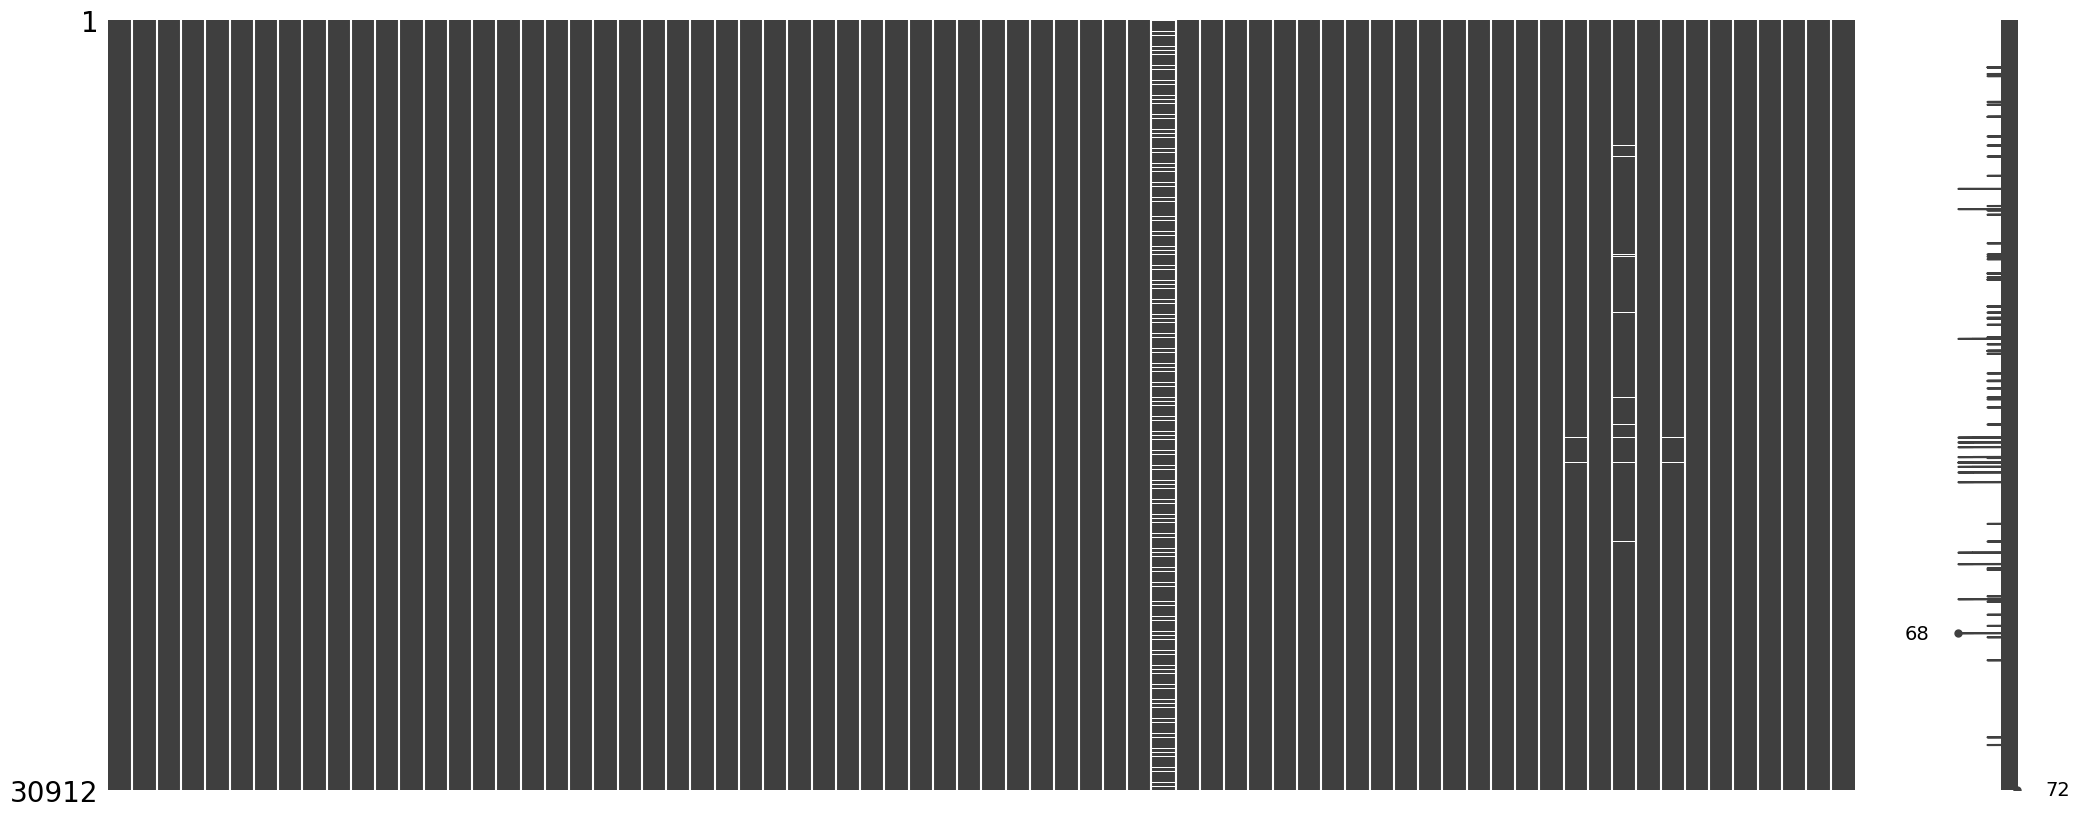

In [72]:
missingno.matrix(merged)

In [73]:
gc.collect()

0

In [74]:
imputer = KNNImputer()

knn_imputer_columns = ['x', 'y', 'month', 'year', 'lst_min', 'lst_max']

temp_df = merged[knn_imputer_columns]

imputed_data = pd.DataFrame(imputer.fit_transform(temp_df), columns = temp_df.columns)
imputed_columns = ['lst_min', 'lst_max']

merged[imputed_columns] = imputed_data[imputed_columns]

<Axes: >

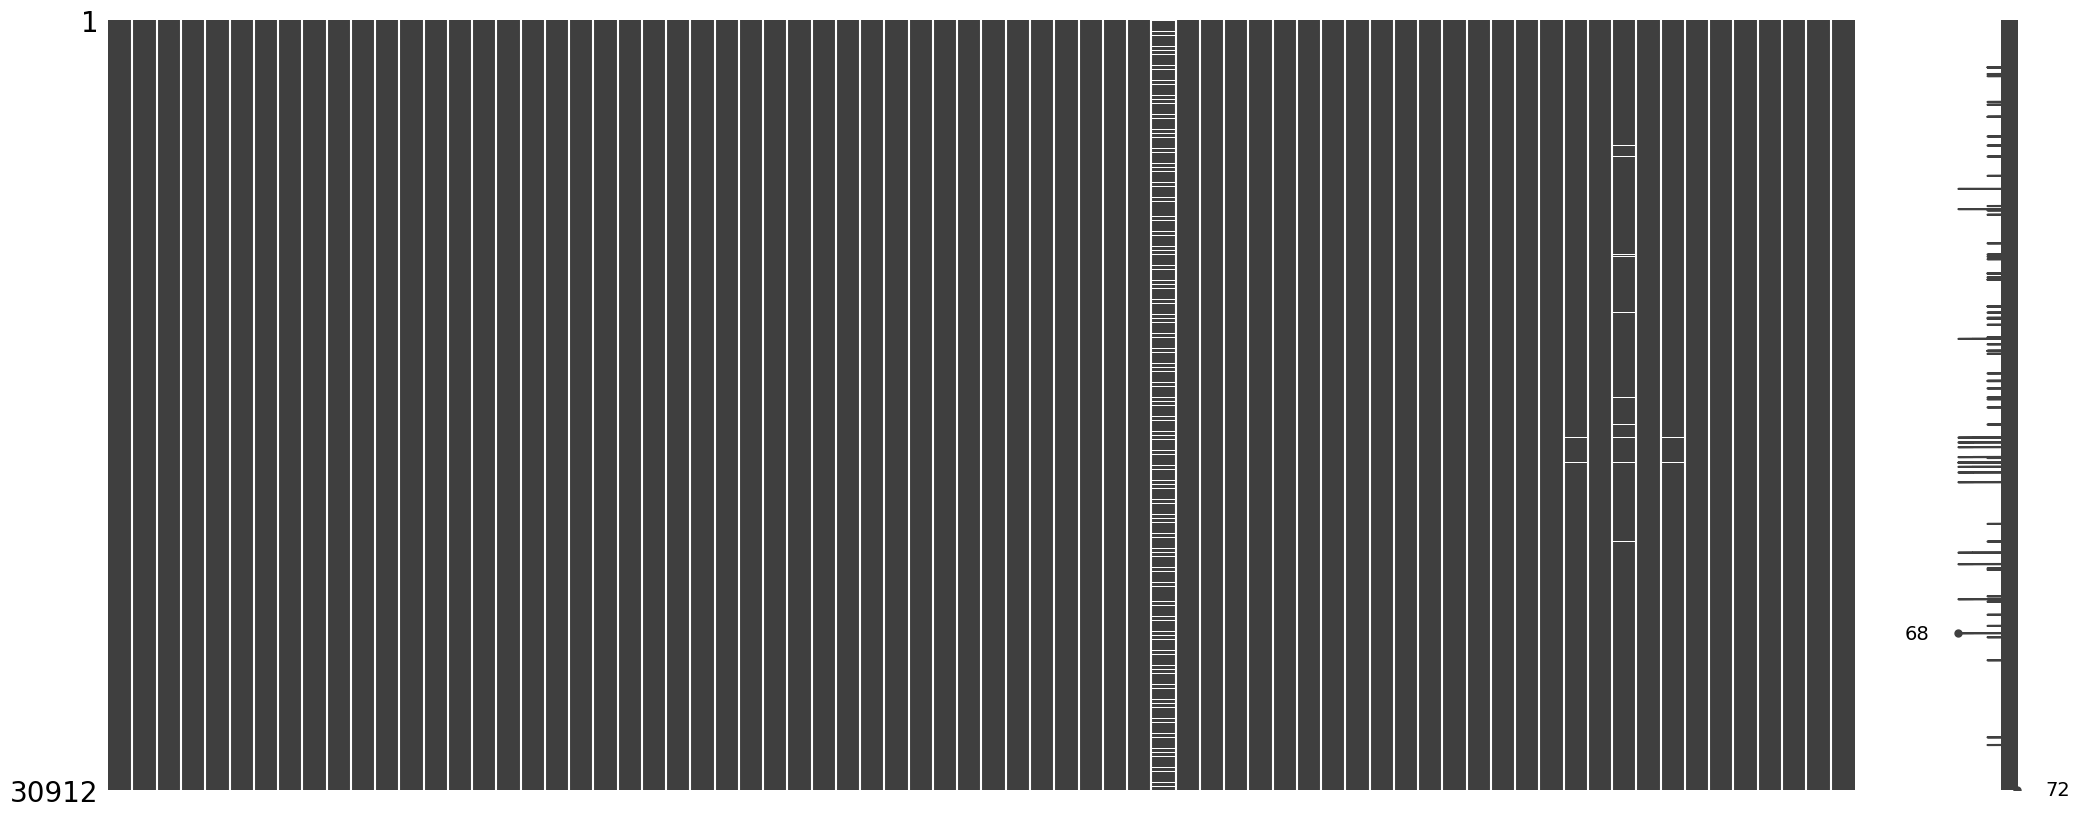

In [75]:
missingno.matrix(merged)

In [76]:
years = merged.year.unique()
years

array([2024])

In [77]:
cell_codes_un = merged.cell_number.unique()
cell_codes_un

array([   0,    1,    2, ..., 4413, 4414, 4415], dtype=int64)

In [78]:
rows = []
for year in years:
    for cell in cell_codes_un:
        filtered_df = merged.loc[(merged['year'] == year) & (merged['cell_number'] == cell)].copy()
        filtered_df.reset_index(drop = True, inplace = True)

        tmin = robjects.IntVector(filtered_df['lst_min'].tolist())
        tmax = robjects.IntVector(filtered_df['lst_max'].tolist())
        prec = robjects.IntVector(filtered_df['rainfall_acc'].tolist())

        bio_vars = list(dismo.biovars(prec, tmin, tmax))

        rows.append({'cell_number': cell, 
                     'year': year, 
                     'bio1': bio_vars[0],
                     'bio2': bio_vars[1],
                     'bio3': bio_vars[2],
                     'bio4': bio_vars[3],
                     'bio5': bio_vars[4],
                     'bio6': bio_vars[5],
                     'bio7': bio_vars[6],
                     'bio8': bio_vars[7],
                     'bio9': bio_vars[8],
                     'bio10': bio_vars[9],
                     'bio11': bio_vars[10],
                     'bio12': bio_vars[11],
                     'bio13': bio_vars[12],
                     'bio14': bio_vars[13],
                     'bio15': bio_vars[14],
                     'bio16': bio_vars[15],
                     'bio17': bio_vars[16],
                     'bio18': bio_vars[17],
                     'bio19': bio_vars[18]})
        
biovars_df = pd.DataFrame(rows)

In [79]:
biovars_df.head(20)

,cell_number,year,bio1,bio2,bio3,bio4,bio5,bio6,bio7,bio8,bio9,bio10,bio11,bio12,bio13,bio14,bio15,bio16,bio17,bio18,bio19
0,0,2024,14.071429,22.142857,54.006969,934.714115,35.000000,-6.000000,41.000000,13.000000,18.333333,22.333333,5.833333,268.000000,70.000000,0.000000,73.843256,186.000000,45.000000,70.000000,128.000000
1,1,2024,12.857143,21.428571,53.571429,890.558947,32.000000,-8.000000,40.000000,11.666667,16.666667,20.500000,5.000000,278.000000,74.000000,0.000000,76.110162,203.000000,28.000000,74.000000,137.000000
2,2,2024,13.000000,20.000000,50.000000,837.655458,32.000000,-8.000000,40.000000,13.333333,15.500000,20.000000,5.500000,278.000000,74.000000,0.000000,76.110162,203.000000,28.000000,74.000000,137.000000
3,3,2024,12.357143,18.142857,51.836735,759.777536,29.000000,-6.000000,35.000000,12.833333,14.500000,18.833333,5.500000,278.000000,74.000000,0.000000,76.110162,203.000000,28.000000,74.000000,137.000000
4,4,2024,14.928571,11.285714,40.306122,777.511292,29.000000,1.000000,28.000000,15.166667,17.666667,21.666667,7.666667,268.000000,70.000000,0.000000,73.843256,186.000000,45.000000,70.000000,128.000000
5,5,2024,14.214286,22.142857,52.721088,917.813136,34.000000,-8.000000,42.000000,13.500000,17.833333,22.000000,5.666667,278.000000,74.000000,0.000000,76.110162,203.000000,28.000000,74.000000,137.000000
6,6,2024,14.714286,20.285714,48.299320,896.222230,35.000000,-7.000000,42.000000,14.666667,17.833333,22.166667,6.833333,278.000000,74.000000,0.000000,76.110162,203.000000,28.000000,74.000000,137.000000
7,7,2024,12.857143,19.142857,51.737452,730.133712,30.000000,-7.000000,37.000000,13.166667,14.833333,19.000000,6.500000,278.000000,74.000000,0.000000,76.110162,203.000000,28.000000,74.000000,137.000000
8,8,2024,13.857143,8.000000,32.000000,781.938982,27.000000,2.000000,25.000000,13.166667,17.500000,21.166667,6.500000,291.000000,96.000000,0.000000,84.344421,215.000000,20.000000,60.000000,135.000000
9,9,2024,13.571429,8.571429,32.967033,760.717080,28.000000,2.000000,26.000000,12.833333,17.000000,20.500000,6.333333,291.000000,96.000000,0.000000,84.344421,215.000000,20.000000,60.000000,135.000000


In [80]:
merged = pd.merge(merged, biovars_df,  how='left', on=['cell_number', 'year'])

In [81]:
##check if biovars have the same value across all months
merged.loc[(merged['year'] == 2024) & (merged['cell_number'] == 0)]

,cell_number,dt_placement,NUTS1_ID,NUTS1_NAME,NUTS2_ID,NUTS2_NAME,NUTS3_ID,NUTS3_NAME,LAU1_NAME,x,y,MOUNT_TYPE,URBN_TYPE,COAST_TYPE,year,month,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst_day_mean,lst_night_mean,lst_mean,lst_jan_day_mean,lst_feb_day_mean,lst_mar_day_mean,lst_apr_day_mean,lst_jan_night_mean,lst_feb_night_mean,lst_mar_night_mean,lst_apr_night_mean,lst_jan_mean,lst_feb_mean,lst_mar_mean,lst_apr_mean,rainfall_mean,acc_rainfall_1week,acc_rainfall_2week,acc_rainfall_month,acc_rainfall_jan,rainfall_acc,lst_min,lst_max,distance_to_coast,distance_to_river,slope_mean_1km,aspect_mean_200m,elevation_mean_1km,hillshade_mean_1km,fs_area_1km,flow_accu_200m,lc_prop1,lc_prop1_assessment,lc_prop2,lc_prop2_assessment,lc_prop3,lc_prop3_assessment,lc_type1,lc_type2,lc_type3,lc_type4,lc_type5,lw,qc,bio1,bio2,bio3,bio4,bio5,bio6,bio7,bio8,bio9,bio10,bio11,bio12,bio13,bio14,bio15,bio16,bio17,bio18,bio19
0,0,2024-01,EL5,βορεια ελλαδα,EL52,κεντρικη μακεδονια,EL524,πελλα,εδεσσας,21.763340,40.798060,2,3,2,2024,1,0.267415,0.083574,-0.257810,-0.083574,0.241783,0.021266,-0.224117,-0.021266,0.021016,0.055956,0.024599,0.055956,6.433226,0.938387,3.685806,6.433226,10.222414,13.967419,23.437200,0.938387,2.737586,2.594516,8.852400,3.685806,6.480000,8.280968,16.144800,1.467828,7.611751,16.225668,45.498087,45.502681,45.502681,-6.610000,12.870000,1448.145975,456.840006,9,75.660308,748.319206,158.266121,0.000000,1.000000,31,80.000000,30,80.000000,30,80.000000,10,10,1,6,6,2,0,14.071429,22.142857,54.006969,934.714115,35.000000,-6.000000,41.000000,13.000000,18.333333,22.333333,5.833333,268.000000,70.000000,0.000000,73.843256,186.000000,45.000000,70.000000,128.000000
1,0,2024-02,EL5,βορεια ελλαδα,EL52,κεντρικη μακεδονια,EL524,πελλα,εδεσσας,21.763340,40.798060,2,3,2,2024,2,0.244531,0.146571,-0.258886,-0.146571,0.290309,-0.085296,-0.307094,0.085296,0.023339,0.022974,0.011478,0.022974,10.222414,2.737586,6.480000,6.433226,10.222414,13.967419,23.437200,0.938387,2.737586,2.594516,8.852400,3.685806,6.480000,8.280968,16.144800,1.294299,18.881823,18.951474,37.534668,83.037349,37.534668,-5.290000,14.110000,1448.145975,456.840006,9,75.660308,748.319206,158.266121,0.000000,1.000000,31,80.000000,30,80.000000,30,80.000000,10,10,1,6,6,2,0,14.071429,22.142857,54.006969,934.714115,35.000000,-6.000000,41.000000,13.000000,18.333333,22.333333,5.833333,268.000000,70.000000,0.000000,73.843256,186.000000,45.000000,70.000000,128.000000
2,0,2024-03,EL5,βορεια ελλαδα,EL52,κεντρικη μακεδονια,EL524,πελλα,εδεσσας,21.763340,40.798060,2,3,2,2024,3,0.324030,-0.109920,-0.337069,0.109920,0.306936,-0.100461,-0.321696,0.100461,0.025461,0.024213,0.015288,0.024213,13.967419,2.594516,8.280968,6.433226,10.222414,13.967419,23.437200,0.938387,2.737586,2.594516,8.852400,3.685806,6.480000,8.280968,16.144800,1.551360,11.947780,14.171614,29.937022,129.578139,46.540790,-4.570000,24.350000,1448.145975,456.840006,9,75.660308,748.319206,158.266121,0.000000,1.000000,31,80.000000,30,80.000000,30,80.000000,10,10,1,6,6,2,0,14.071429,22.142857,54.006969,934.714115,35.000000,-6.000000,41.000000,13.000000,18.333333,22.333333,5.833333,268.000000,70.000000,0.000000,73.843256,186.000000,45.000000,70.000000,128.000000
3,0,2024-04,EL5,βορεια ελλαδα,EL52,κεντρικη μακεδονια,EL524,πελλα,εδεσσας,21.763340,40.798060,2,3,2,2024,4,0.498411,0.043862,-0.419718,-0.043862,0.471756,0.023727,-0.406067,-0.023727,0.044087,0.046540,0.023812,0.046540,23.437200,8.852400,16.144800,6.433226,10.222414,13.967419,23.437200,0.938387,2.737586,2.594516,8.852400,3.685806,6.480000,8.280968,16.144800,2.423561,0.703507,60.256993,70.283258,199.861397,70.283258,-1.550000,29.210000,1448.145975,456.840006,9,75.660308,748.319206,158.266121,0.000000,1.000000,31,80.000000,30,80.000000,30,80.000000,10,10,1,6,6,2,0,14.071429,22.142857,54.006969,934.714115,35.000000,-6.000000,41.000000,13.000000,18.333333,22.333333,5.833333,268.000000,70.000000,0.000000,73.843256,186.000000,45.000000,70.000000,128.00

In [82]:
df_demographics = pd.read_csv(r'E:\Drive\NOA\MBD-Prediction\NUTS3 Level\Greece\data\GR_EUROSTAT_Demographics_Processed.csv', encoding = enc)

In [83]:
df_demographics

,NUTS3_CODE,YEAR,M_Y_LT15,M_Y15-64,M_Y_GE65,M_TOTAL,F_Y_LT15,F_Y15-64,F_Y_GE65,F_TOTAL
0,EL301,1991,51138.000000,165030.000000,25941.000000,242109.000000,48144.000000,183544.000000,33859.000000,265547.000000
1,EL301,1992,50517.000000,170015.000000,27446.000000,247978.000000,47283.000000,188320.000000,35622.000000,271225.000000
2,EL301,1993,49861.000000,173915.000000,28721.000000,252497.000000,46367.000000,192179.000000,37065.000000,275611.000000
3,EL301,1994,48815.000000,177441.000000,30222.000000,256478.000000,45313.000000,195444.000000,38973.000000,279730.000000
4,EL301,1995,47801.000000,180431.000000,31701.000000,259933.000000,44292.000000,198519.000000,40741.000000,283552.000000
...,...,...,...,...,...,...,...,...,...,...
1711,EL653,2019,16325.000000,78167.000000,30253.000000,124745.000000,16020.000000,74725.000000,32974.000000,123719.000000
1712,EL653,2020,16045.000000,77750.000000,30621.000000,124416.000000,15854.000000,74339.000000,33180.000000,123373.000000
1713,EL653,2021,15742.000000,77179.000000,31111.000000,124032.000000,15590.000000,73901.000000,33433.000000,122924.000000
1714,EL653,2022,14396.000000,72340.000000,29251.000000,115987.000000,13728.000000,67675.000000,32412.000000,113815.000000


In [84]:
df_demographics.rename(columns={'NUTS3_CODE': 'NUTS3_ID', 'YEAR': 'year'}, inplace=True)

In [85]:
df_demographics

,NUTS3_ID,year,M_Y_LT15,M_Y15-64,M_Y_GE65,M_TOTAL,F_Y_LT15,F_Y15-64,F_Y_GE65,F_TOTAL
0,EL301,1991,51138.000000,165030.000000,25941.000000,242109.000000,48144.000000,183544.000000,33859.000000,265547.000000
1,EL301,1992,50517.000000,170015.000000,27446.000000,247978.000000,47283.000000,188320.000000,35622.000000,271225.000000
2,EL301,1993,49861.000000,173915.000000,28721.000000,252497.000000,46367.000000,192179.000000,37065.000000,275611.000000
3,EL301,1994,48815.000000,177441.000000,30222.000000,256478.000000,45313.000000,195444.000000,38973.000000,279730.000000
4,EL301,1995,47801.000000,180431.000000,31701.000000,259933.000000,44292.000000,198519.000000,40741.000000,283552.000000
...,...,...,...,...,...,...,...,...,...,...
1711,EL653,2019,16325.000000,78167.000000,30253.000000,124745.000000,16020.000000,74725.000000,32974.000000,123719.000000
1712,EL653,2020,16045.000000,77750.000000,30621.000000,124416.000000,15854.000000,74339.000000,33180.000000,123373.000000
1713,EL653,2021,15742.000000,77179.000000,31111.000000,124032.000000,15590.000000,73901.000000,33433.000000,122924.000000
1714,EL653,2022,14396.000000,72340.000000,29251.000000,115987.000000,13728.000000,67675.000000,32412.000000,113815.000000


In [86]:
dataset = pd.merge(merged, df_demographics,  how='left', on=['NUTS3_ID', 'year'])

<Axes: >

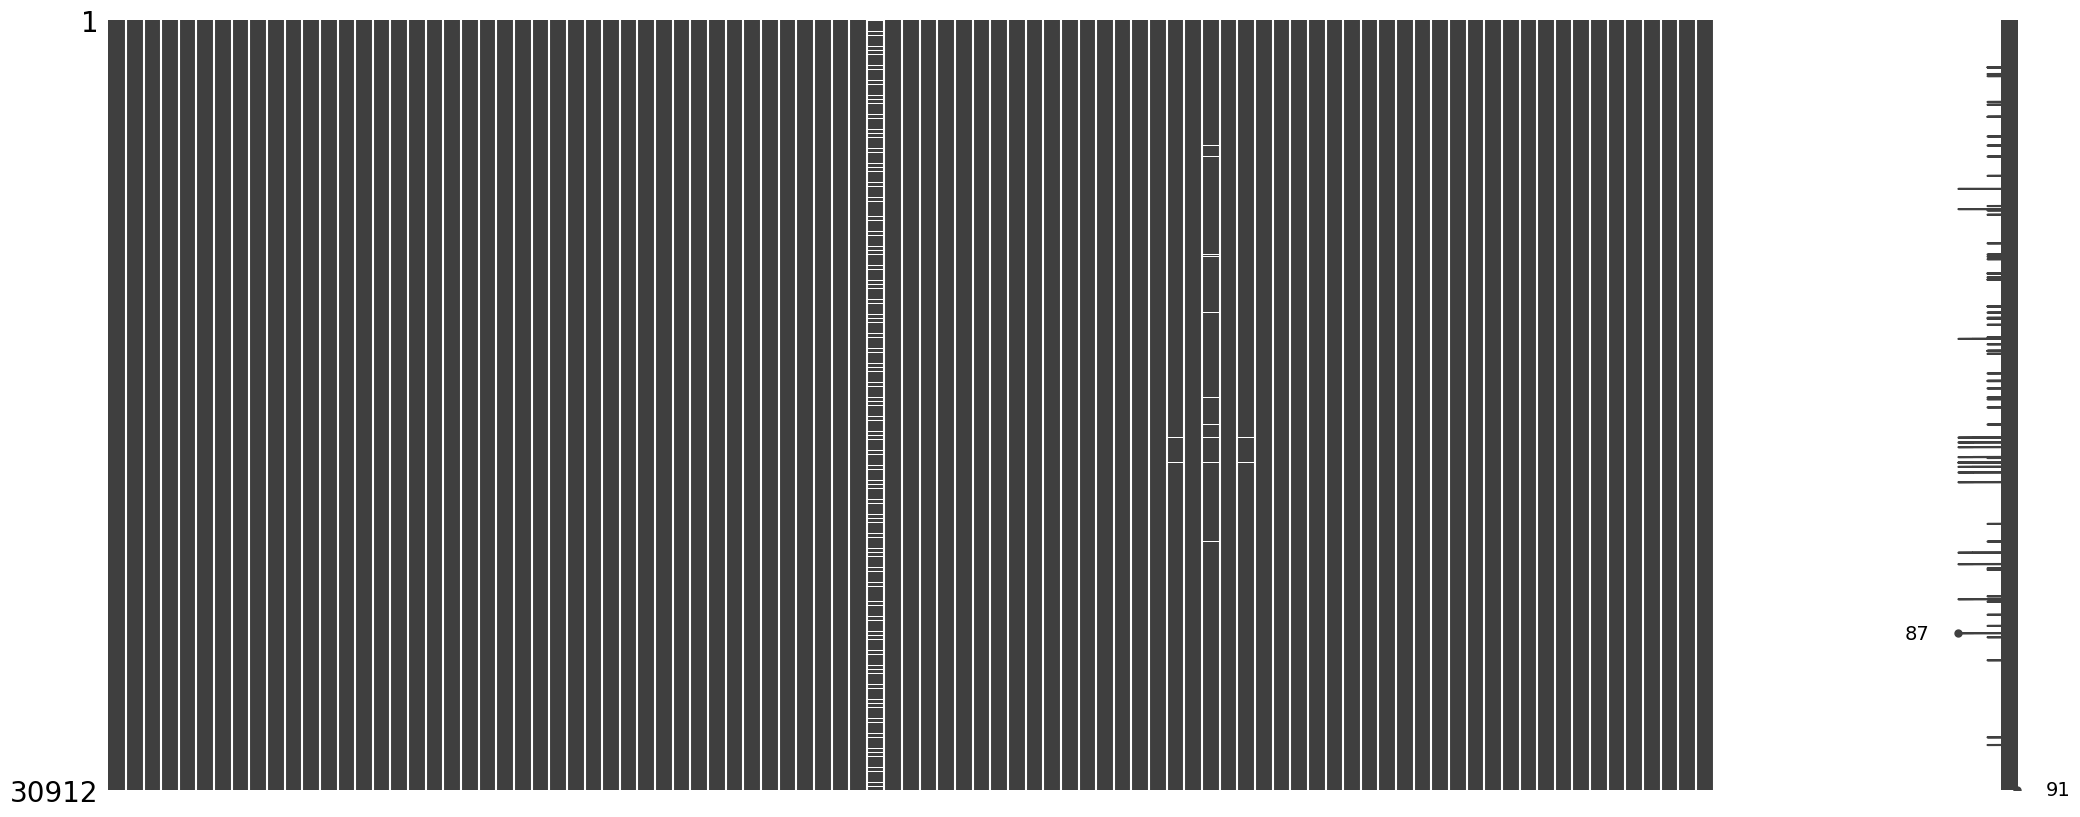

In [87]:
missingno.matrix(dataset)

In [88]:
df_economics = pd.read_csv(r'E:\Drive\NOA\MBD-Prediction\NUTS3 Level\Greece\data\GR_EUROSTAT_Economics_Processed.csv', encoding = enc)

In [89]:
df_economics

,NUTS3_CODE,YEAR,MIO_EUR
0,EL301,2000,10002.340000
1,EL301,2001,10677.520000
2,EL301,2002,12022.340000
3,EL301,2003,12784.960000
4,EL301,2004,14149.980000
...,...,...,...
1139,EL653,2017,3112.330000
1140,EL653,2018,3111.760000
1141,EL653,2019,3149.580000
1142,EL653,2020,2795.860000


In [90]:
df_economics.rename(columns={'NUTS3_CODE': 'NUTS3_ID', 'YEAR': 'year'}, inplace=True)

In [91]:
df_economics

,NUTS3_ID,year,MIO_EUR
0,EL301,2000,10002.340000
1,EL301,2001,10677.520000
2,EL301,2002,12022.340000
3,EL301,2003,12784.960000
4,EL301,2004,14149.980000
...,...,...,...
1139,EL653,2017,3112.330000
1140,EL653,2018,3111.760000
1141,EL653,2019,3149.580000
1142,EL653,2020,2795.860000


In [92]:
dataset = pd.merge(dataset, df_economics,  how='left', on=['NUTS3_ID', 'year'])

<Axes: >

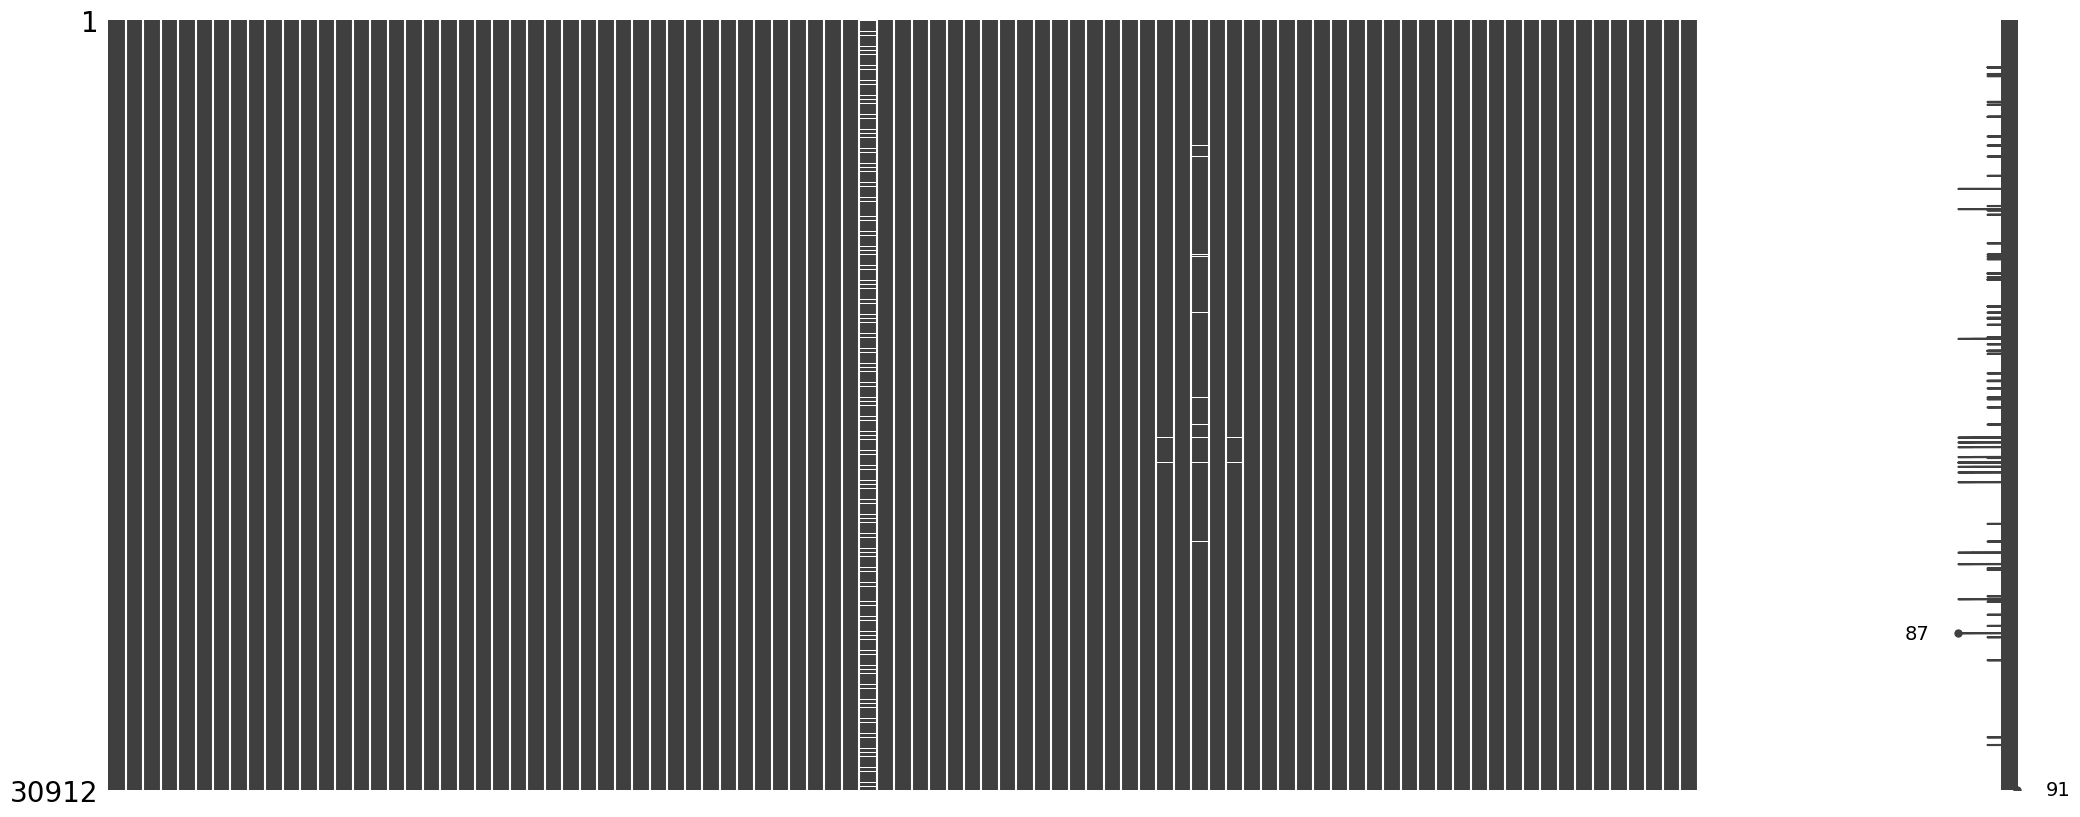

In [93]:
missingno.matrix(dataset)

In [94]:
df_trade = pd.read_csv(r'E:\Drive\NOA\MBD-Prediction\NUTS3 Level\Greece\data\GR_EUROSTAT_Trade_Processed.csv', encoding = enc)

In [95]:
df_trade

,NUTS3_CODE,YEAR,L_TOTAL,UNL_TOTAL
0,EL111,2008,6704.000000,7125.000000
1,EL111,2009,3031.000000,3303.000000
2,EL111,2010,2663.000000,2085.000000
3,EL111,2011,4163.000000,4212.000000
4,EL111,2012,4379.000000,5029.000000
...,...,...,...,...
766,EL653,2018,2358.000000,2885.000000
767,EL653,2019,2914.000000,3549.000000
768,EL653,2020,4572.000000,4962.000000
769,EL653,2021,3040.000000,3666.000000


In [96]:
df_trade.rename(columns={'NUTS3_CODE': 'NUTS3_ID', 'YEAR': 'year'}, inplace=True)

In [97]:
df_trade

,NUTS3_ID,year,L_TOTAL,UNL_TOTAL
0,EL111,2008,6704.000000,7125.000000
1,EL111,2009,3031.000000,3303.000000
2,EL111,2010,2663.000000,2085.000000
3,EL111,2011,4163.000000,4212.000000
4,EL111,2012,4379.000000,5029.000000
...,...,...,...,...
766,EL653,2018,2358.000000,2885.000000
767,EL653,2019,2914.000000,3549.000000
768,EL653,2020,4572.000000,4962.000000
769,EL653,2021,3040.000000,3666.000000


In [98]:
dataset = pd.merge(dataset, df_trade,  how='left', on=['NUTS3_ID', 'year'])

<Axes: >

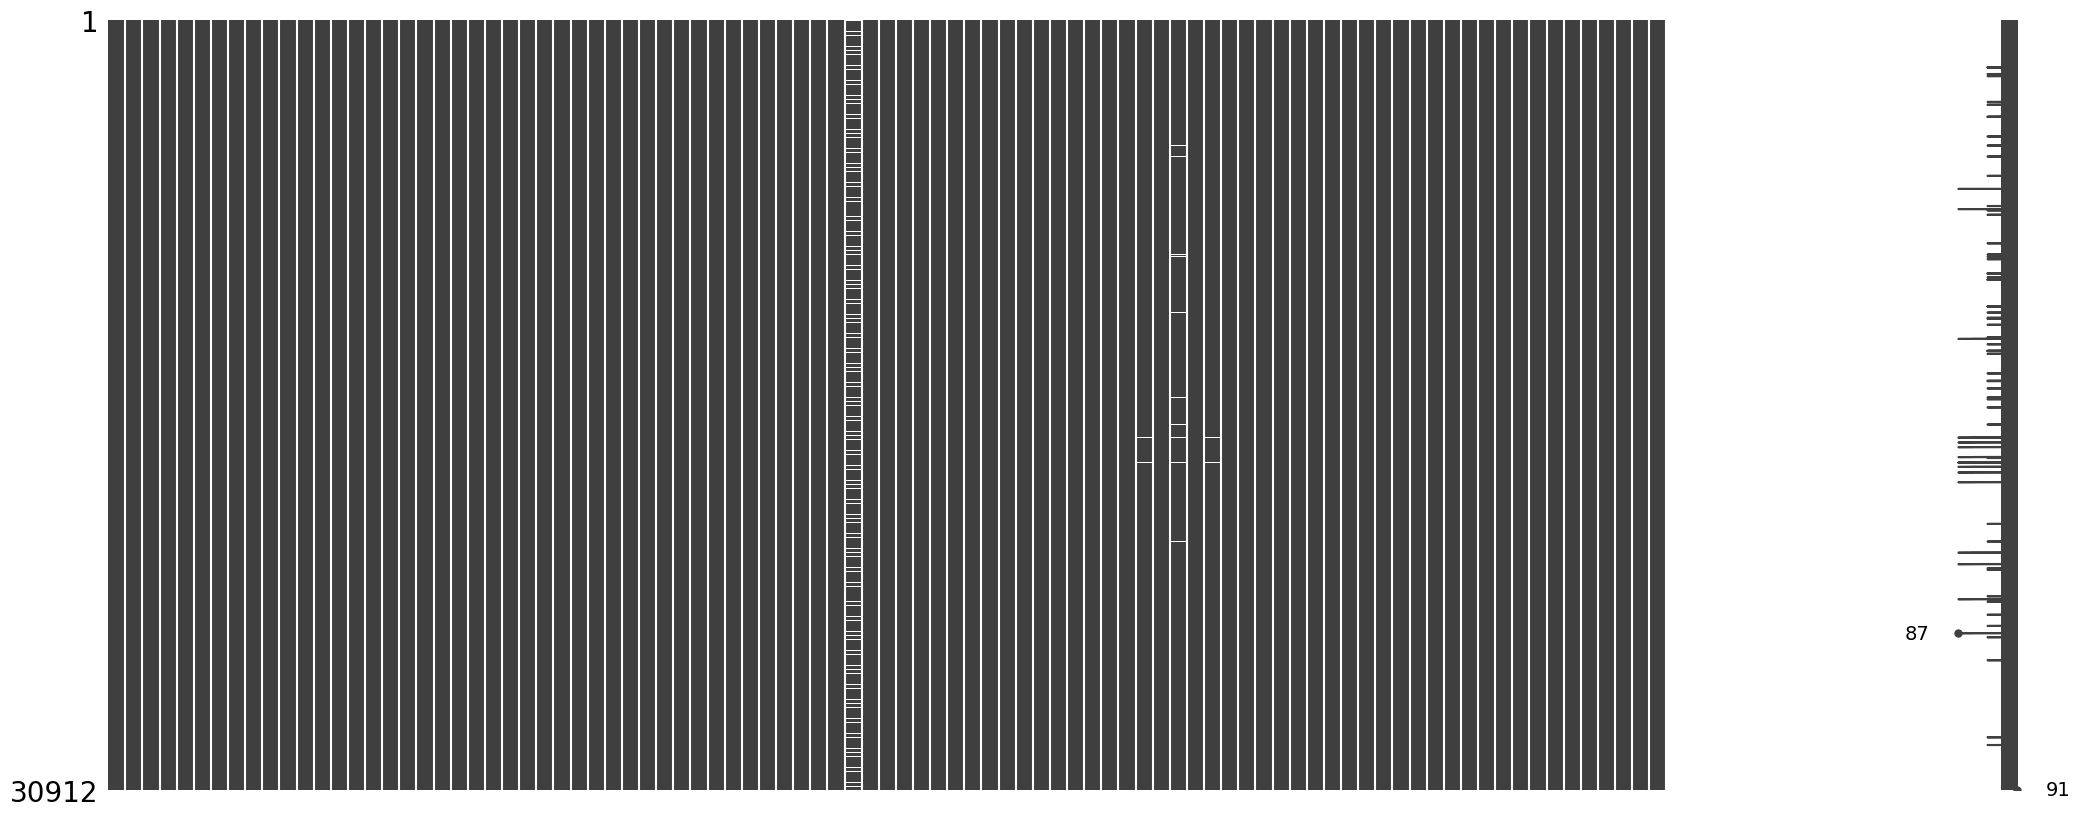

In [99]:
missingno.matrix(dataset)

In [100]:
missing = describe_dataframe(dataset, remove_zeros=True)

In [101]:
missing

,Column,Missing
16,ndvi,0.006500
17,ndmi,0.006500
18,ndwi,0.006500
19,ndbi,0.006500
43,rainfall_mean,14.285700
60,lc_prop1_assessment,0.317000
62,lc_prop2_assessment,1.607800
64,lc_prop3_assessment,0.317000
91,M_Y_LT15,100.000000
92,M_Y15-64,100.000000


In [102]:
dataset

,cell_number,dt_placement,NUTS1_ID,NUTS1_NAME,NUTS2_ID,NUTS2_NAME,NUTS3_ID,NUTS3_NAME,LAU1_NAME,x,y,MOUNT_TYPE,URBN_TYPE,COAST_TYPE,year,month,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst_day_mean,lst_night_mean,lst_mean,lst_jan_day_mean,lst_feb_day_mean,lst_mar_day_mean,lst_apr_day_mean,lst_jan_night_mean,lst_feb_night_mean,lst_mar_night_mean,lst_apr_night_mean,lst_jan_mean,lst_feb_mean,lst_mar_mean,lst_apr_mean,rainfall_mean,acc_rainfall_1week,acc_rainfall_2week,acc_rainfall_month,acc_rainfall_jan,rainfall_acc,lst_min,lst_max,distance_to_coast,distance_to_river,slope_mean_1km,aspect_mean_200m,elevation_mean_1km,hillshade_mean_1km,fs_area_1km,flow_accu_200m,lc_prop1,lc_prop1_assessment,lc_prop2,lc_prop2_assessment,lc_prop3,lc_prop3_assessment,lc_type1,lc_type2,lc_type3,lc_type4,lc_type5,lw,qc,bio1,bio2,bio3,bio4,bio5,bio6,bio7,bio8,bio9,bio10,bio11,bio12,bio13,bio14,bio15,bio16,bio17,bio18,bio19,M_Y_LT15,M_Y15-64,M_Y_GE65,M_TOTAL,F_Y_LT15,F_Y15-64,F_Y_GE65,F_TOTAL,MIO_EUR,L_TOTAL,UNL_TOTAL
0,0,2024-01,EL5,βορεια ελλαδα,EL52,κεντρικη μακεδονια,EL524,πελλα,εδεσσας,21.763340,40.798060,2,3,2,2024,1,0.267415,0.083574,-0.257810,-0.083574,0.241783,0.021266,-0.224117,-0.021266,0.021016,0.055956,0.024599,0.055956,6.433226,0.938387,3.685806,6.433226,10.222414,13.967419,23.437200,0.938387,2.737586,2.594516,8.852400,3.685806,6.480000,8.280968,16.144800,1.467828,7.611751,16.225668,45.498087,45.502681,45.502681,-6.610000,12.870000,1448.145975,456.840006,9,75.660308,748.319206,158.266121,0.000000,1.000000,31,80.000000,30,80.000000,30,80.000000,10,10,1,6,6,2,0,14.071429,22.142857,54.006969,934.714115,35.000000,-6.000000,41.000000,13.000000,18.333333,22.333333,5.833333,268.000000,70.000000,0.000000,73.843256,186.000000,45.000000,70.000000,128.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,0,2024-02,EL5,βορεια ελλαδα,EL52,κεντρικη μακεδονια,EL524,πελλα,εδεσσας,21.763340,40.798060,2,3,2,2024,2,0.244531,0.146571,-0.258886,-0.146571,0.290309,-0.085296,-0.307094,0.085296,0.023339,0.022974,0.011478,0.022974,10.222414,2.737586,6.480000,6.433226,10.222414,13.967419,23.437200,0.938387,2.737586,2.594516,8.852400,3.685806,6.480000,8.280968,16.144800,1.294299,18.881823,18.951474,37.534668,83.037349,37.534668,-5.290000,14.110000,1448.145975,456.840006,9,75.660308,748.319206,158.266121,0.000000,1.000000,31,80.000000,30,80.000000,30,80.000000,10,10,1,6,6,2,0,14.071429,22.142857,54.006969,934.714115,35.000000,-6.000000,41.000000,13.000000,18.333333,22.333333,5.833333,268.000000,70.000000,0.000000,73.843256,186.000000,45.000000,70.000000,128.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,0,2024-03,EL5,βορεια ελλαδα,EL52,κεντρικη μακεδονια,EL524,πελλα,εδεσσας,21.763340,40.798060,2,3,2,2024,3,0.324030,-0.109920,-0.337069,0.109920,0.306936,-0.100461,-0.321696,0.100461,0.025461,0.024213,0.015288,0.024213,13.967419,2.594516,8.280968,6.433226,10.222414,13.967419,23.437200,0.938387,2.737586,2.594516,8.852400,3.685806,6.480000,8.280968,16.144800,1.551360,11.947780,14.171614,29.937022,129.578139,46.540790,-4.570000,24.350000,1448.145975,456.840006,9,75.660308,748.319206,158.266121,0.000000,1.000000,31,80.000000,30,80.000000,30,80.000000,10,10,1,6,6,2,0,14.071429,22.142857,54.006969,934.714115,35.000000,-6.000000,41.000000,13.000000,18.333333,22.333333,5.833333,268.000000,70.000000,0.000000,73.843256,186.000000,45.000000,70.000000,128.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,0,2024-04,EL5,βορεια ελλαδα,EL52,κεντρικη μακεδονια,EL524,πελλα,εδεσσας,21.763340,40.798060,2,3,2,2024,4,0.498411,0.043862,-0.419718,-0.043862,0.471756,0.023727,-0.406067,-0.023727,0.044087,0.046540,0.023812,0.046540,23.437200,8.852400,16.144800,6.433226,10.222414,13.967419,23.437200,0.938387,2.737586,2.594516,8.852400,3.685806,6.480000,8.280968,16.144800,2.423561,0.703507,60.256993,70.283258,199.861397,70.283258,-1.550000,29.210000,1448.145975,456.840006,9,75.660308,748.319206,158.266121,0.000000,1.000000,31,80.000000,3

In [103]:
dataset.reset_index(inplace=True, drop=True)

In [104]:
# dataset['cases'].value_counts()

In [105]:
# dataset['cases'].sum()

In [106]:
dataset

,cell_number,dt_placement,NUTS1_ID,NUTS1_NAME,NUTS2_ID,NUTS2_NAME,NUTS3_ID,NUTS3_NAME,LAU1_NAME,x,y,MOUNT_TYPE,URBN_TYPE,COAST_TYPE,year,month,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst_day_mean,lst_night_mean,lst_mean,lst_jan_day_mean,lst_feb_day_mean,lst_mar_day_mean,lst_apr_day_mean,lst_jan_night_mean,lst_feb_night_mean,lst_mar_night_mean,lst_apr_night_mean,lst_jan_mean,lst_feb_mean,lst_mar_mean,lst_apr_mean,rainfall_mean,acc_rainfall_1week,acc_rainfall_2week,acc_rainfall_month,acc_rainfall_jan,rainfall_acc,lst_min,lst_max,distance_to_coast,distance_to_river,slope_mean_1km,aspect_mean_200m,elevation_mean_1km,hillshade_mean_1km,fs_area_1km,flow_accu_200m,lc_prop1,lc_prop1_assessment,lc_prop2,lc_prop2_assessment,lc_prop3,lc_prop3_assessment,lc_type1,lc_type2,lc_type3,lc_type4,lc_type5,lw,qc,bio1,bio2,bio3,bio4,bio5,bio6,bio7,bio8,bio9,bio10,bio11,bio12,bio13,bio14,bio15,bio16,bio17,bio18,bio19,M_Y_LT15,M_Y15-64,M_Y_GE65,M_TOTAL,F_Y_LT15,F_Y15-64,F_Y_GE65,F_TOTAL,MIO_EUR,L_TOTAL,UNL_TOTAL
0,0,2024-01,EL5,βορεια ελλαδα,EL52,κεντρικη μακεδονια,EL524,πελλα,εδεσσας,21.763340,40.798060,2,3,2,2024,1,0.267415,0.083574,-0.257810,-0.083574,0.241783,0.021266,-0.224117,-0.021266,0.021016,0.055956,0.024599,0.055956,6.433226,0.938387,3.685806,6.433226,10.222414,13.967419,23.437200,0.938387,2.737586,2.594516,8.852400,3.685806,6.480000,8.280968,16.144800,1.467828,7.611751,16.225668,45.498087,45.502681,45.502681,-6.610000,12.870000,1448.145975,456.840006,9,75.660308,748.319206,158.266121,0.000000,1.000000,31,80.000000,30,80.000000,30,80.000000,10,10,1,6,6,2,0,14.071429,22.142857,54.006969,934.714115,35.000000,-6.000000,41.000000,13.000000,18.333333,22.333333,5.833333,268.000000,70.000000,0.000000,73.843256,186.000000,45.000000,70.000000,128.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,0,2024-02,EL5,βορεια ελλαδα,EL52,κεντρικη μακεδονια,EL524,πελλα,εδεσσας,21.763340,40.798060,2,3,2,2024,2,0.244531,0.146571,-0.258886,-0.146571,0.290309,-0.085296,-0.307094,0.085296,0.023339,0.022974,0.011478,0.022974,10.222414,2.737586,6.480000,6.433226,10.222414,13.967419,23.437200,0.938387,2.737586,2.594516,8.852400,3.685806,6.480000,8.280968,16.144800,1.294299,18.881823,18.951474,37.534668,83.037349,37.534668,-5.290000,14.110000,1448.145975,456.840006,9,75.660308,748.319206,158.266121,0.000000,1.000000,31,80.000000,30,80.000000,30,80.000000,10,10,1,6,6,2,0,14.071429,22.142857,54.006969,934.714115,35.000000,-6.000000,41.000000,13.000000,18.333333,22.333333,5.833333,268.000000,70.000000,0.000000,73.843256,186.000000,45.000000,70.000000,128.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,0,2024-03,EL5,βορεια ελλαδα,EL52,κεντρικη μακεδονια,EL524,πελλα,εδεσσας,21.763340,40.798060,2,3,2,2024,3,0.324030,-0.109920,-0.337069,0.109920,0.306936,-0.100461,-0.321696,0.100461,0.025461,0.024213,0.015288,0.024213,13.967419,2.594516,8.280968,6.433226,10.222414,13.967419,23.437200,0.938387,2.737586,2.594516,8.852400,3.685806,6.480000,8.280968,16.144800,1.551360,11.947780,14.171614,29.937022,129.578139,46.540790,-4.570000,24.350000,1448.145975,456.840006,9,75.660308,748.319206,158.266121,0.000000,1.000000,31,80.000000,30,80.000000,30,80.000000,10,10,1,6,6,2,0,14.071429,22.142857,54.006969,934.714115,35.000000,-6.000000,41.000000,13.000000,18.333333,22.333333,5.833333,268.000000,70.000000,0.000000,73.843256,186.000000,45.000000,70.000000,128.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,0,2024-04,EL5,βορεια ελλαδα,EL52,κεντρικη μακεδονια,EL524,πελλα,εδεσσας,21.763340,40.798060,2,3,2,2024,4,0.498411,0.043862,-0.419718,-0.043862,0.471756,0.023727,-0.406067,-0.023727,0.044087,0.046540,0.023812,0.046540,23.437200,8.852400,16.144800,6.433226,10.222414,13.967419,23.437200,0.938387,2.737586,2.594516,8.852400,3.685806,6.480000,8.280968,16.144800,2.423561,0.703507,60.256993,70.283258,199.861397,70.283258,-1.550000,29.210000,1448.145975,456.840006,9,75.660308,748.319206,158.266121,0.000000,1.000000,31,80.000000,3

In [107]:
cols = dataset.columns

In [108]:
print(cols)


Index(['cell_number', 'dt_placement', 'NUTS1_ID', 'NUTS1_NAME', 'NUTS2_ID',
       'NUTS2_NAME', 'NUTS3_ID', 'NUTS3_NAME', 'LAU1_NAME', 'x',
       ...
       'M_Y15-64', 'M_Y_GE65', 'M_TOTAL', 'F_Y_LT15', 'F_Y15-64', 'F_Y_GE65',
       'F_TOTAL', 'MIO_EUR', 'L_TOTAL', 'UNL_TOTAL'],
      dtype='object', length=102)


In [109]:
len(cols)

102

In [110]:
years = dataset.year.unique().tolist()

In [111]:
for item in years:
    dataset[dataset.year == item].to_csv(f"../../data/{NUTS2}/{NUTS0}_{NUTS2}_WNV_Dataset_GRID_{item}.csv", encoding = enc, index = False)